In [12]:
import sklearn
import numpy as np
import pandas as pd
import os
import datetime as dt
import sys 
import importlib
import pickle
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from collections import Counter
sklearn.set_config(enable_metadata_routing=False)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
from xgboost import XGBClassifier, XGBRegressor
import time 
import pandas as pd
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import pearsonr
import plotly.express as px
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns



############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables
from scripts import feature_selection as fs
from scripts import clustering as cl

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(cl)

# Filepaths
brighten_dir = paths.DATA
sub_dir = paths.SUB_DFS
results_dir = paths.RESULTS



################ DEFINE column variables from data ###################
from scripts.variables import id_columns
from scripts.variables import all_cols, all_daily_cols, weekly_cols, baseline_cols, drop_weekly_cols
from scripts.variables import daily_cols_v1, daily_v2_sensor_hr, daily_v2_weather, daily_cols_v2 
from scripts.variables import gad_cols, phq9_base, alc_cols, phq9_cols, phq2_cols, sleep_cols, gic_cols, sds_cols


# Define label variables
df_names = ['v1_day', 'v2_day', 'v1_week', 'v2_week']
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes


########################################## MODELS #######################################


# Models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
# Dummy baseline model
class GroupMeanRegressor(BaseEstimator, RegressorMixin):
	def fit(self, X, y, groups):
		self.group_means_ = y.groupby(groups.squeeze()).mean().squeeze()
		self.global_mean_ = y.mean().squeeze()
		return self
	
	def predict(self, X, groups):
		return groups.squeeze().map(self.group_means_).fillna(self.global_mean_).values

# Pearson scorer
def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

models = {
	'Random Forest': RandomForestRegressor(random_state=42),
	'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
	'Hist Gradient Boost': HistGradientBoostingRegressor(),
	'Group Mean': GroupMeanRegressor(),
	'Ridge': Ridge(alpha=1.0)
}
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr

def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

scoring_metrics = {
	'r2': 'r2',
	'neg_mae': 'neg_mean_absolute_error',
	'neg_rmse': 'neg_root_mean_squared_error',
}



def safe_r2(y_true, y_pred, min_std=1e-6):
    if y_true.std() < min_std:
        return np.nan  # undefined / unreliable
    return r2_score(y_true, y_pred)



In [5]:
# Just so i can view them :3
a_v1day_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v1_day_trainval_pca.csv'))
a_v1week_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v1_week_trainval_pca.csv'))
a_v2day_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v2_day_trainval_pca.csv'))
a_v2week_pca_df = pd.read_csv(os.path.join(brighten_dir, 'v2_week_trainval_pca.csv'))


my pipeline: 
1. remove outliers
4. apply log transform to skewed or wide-tailed data
5. remove too-skewed data
6. Impute
7. Scale
8. Drop columns with too few unique values or too little variance

### Load in ANOVA and LME feature dicts

In [5]:
import pickle
with open(os.path.join(brighten_dir, 'anova_features.pkl'), 'rb') as f:
    anova_features = pickle.load(f)
    
with open(os.path.join(brighten_dir,'top_subj_anova_features.pkl'), 'rb') as f:
    top_subj_features = pickle.load(f)

with open(os.path.join(brighten_dir,'lme_features.pkl'), 'rb') as f:
    lme_features = pickle.load(f)


# Try doing by-subject with top correlated columns

For 13.0, X-cols: ['sleep_2', 'sleep_1', 'sds_3', 'season_fall', 'season_num_1.0', 'season_num_4.0', 'season_summer', 'mobility_radius', 'sms_length', 'stress']


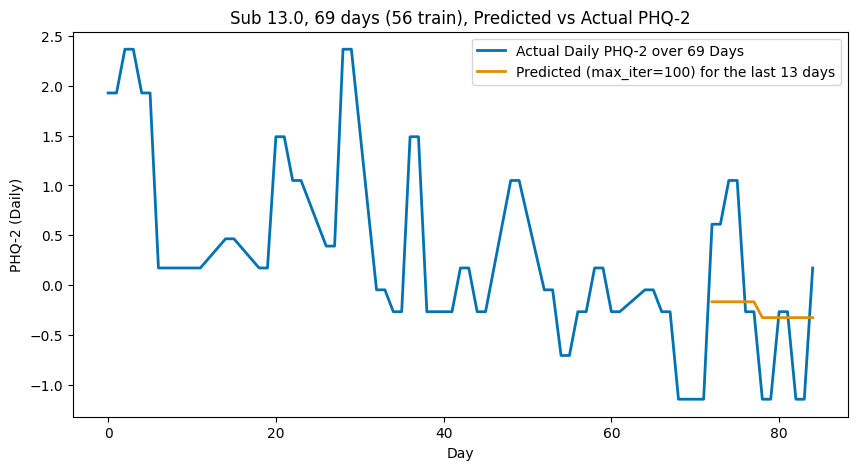

For 14.0, X-cols: ['sds_2', 'sds_3', 'sleep_2', 'mobility', 'stress', 'sds_1', 'mood_1', 'cohort_PST', 'mobility_radius', 'interaction_diversity']


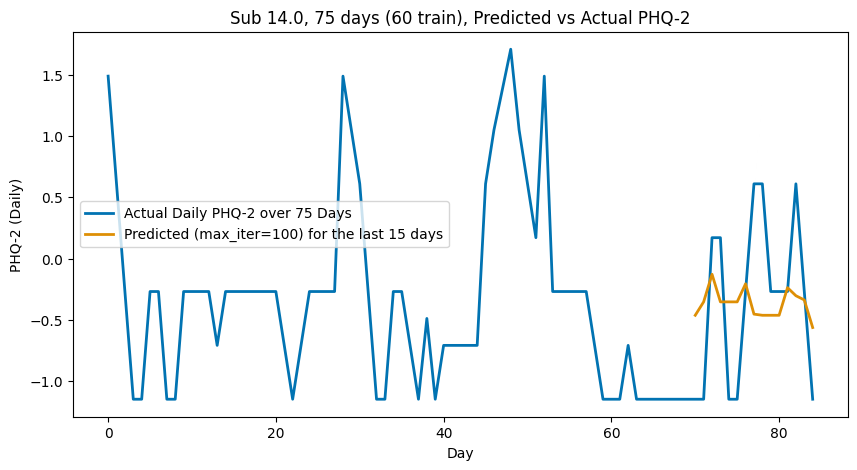

For 17.0, X-cols: ['sds_3', 'sds_1', 'support', 'sds_2', 'aggregate_communication', 'interaction_diversity', 'sms_count', 'sms_length', 'season_fall', 'season_num_1.0']


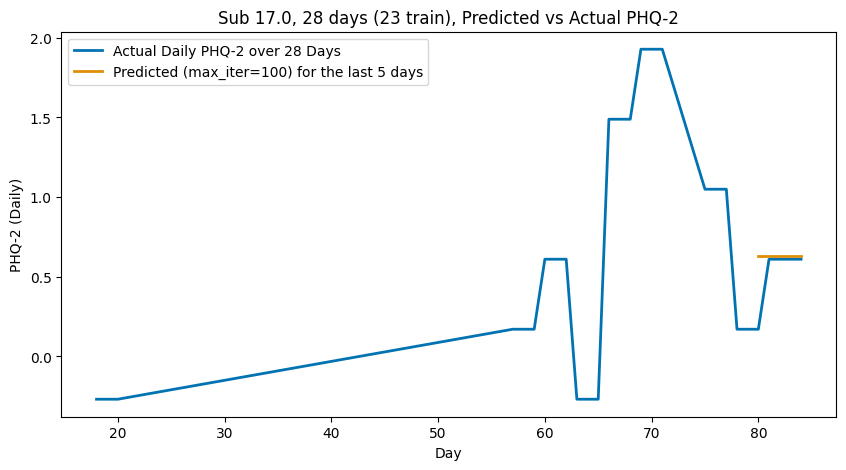

For 29.0, X-cols: ['sds_1', 'sms_length', 'sleep_2', 'sleep_3', 'stress', 'sms_count', 'mobility_radius', 'call_count', 'interaction_diversity', 'mobility']


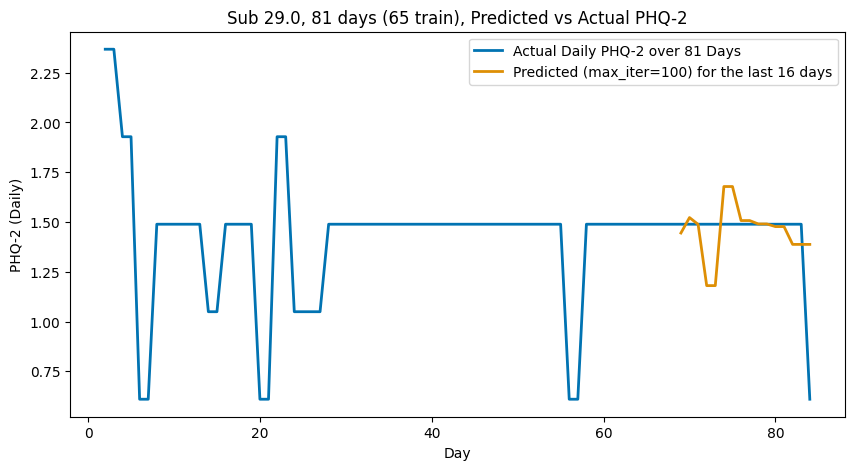

For 166.0, X-cols: ['hours_walking', 'dew_point_mean', 'distance_walking', 'dew_point_median', 'humidity_median', 'hours_active_hr', 'dew_point_std', 'cloud_cover_IQR', 'distance_active_hr', 'distance_walking_hr']


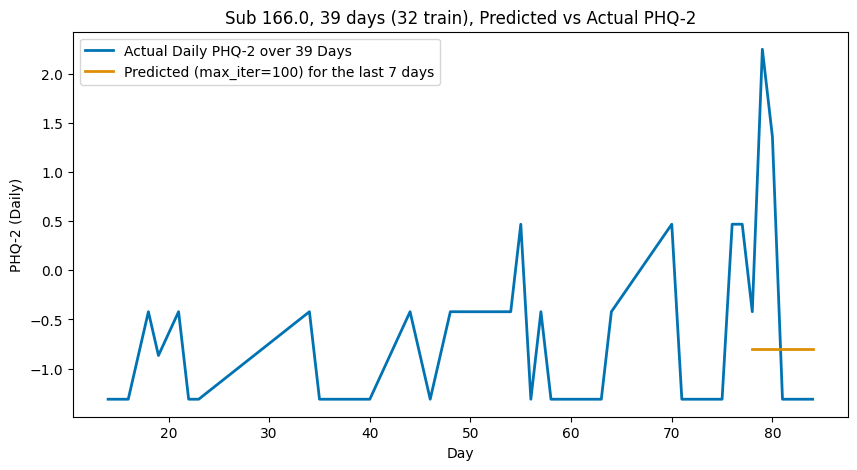

For 179.0, X-cols: ['sds_1', 'sds_2', 'sds_3', 'temp_std', 'humidity_IQR', 'temp_IQR', 'sleep_1', 'sleep_3', 'cloud_cover_mean', 'humidity_std']


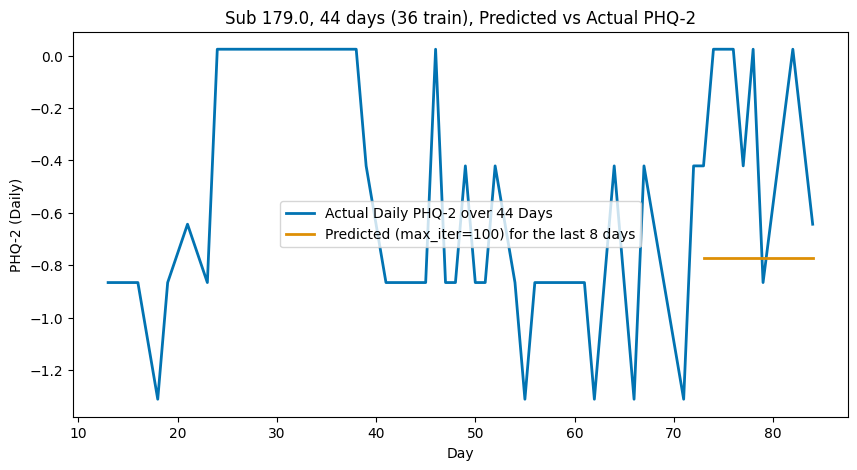

For 180.0, X-cols: ['cloud_cover_std', 'dew_point_std', 'hours_of_sleep_hr.3', 'hours_of_sleep_hr.1', 'hours_of_sleep_hr', 'hours_of_sleep_hr.2', 'sds_3', 'cloud_cover_IQR', 'location_variance_hr', 'sds_2']


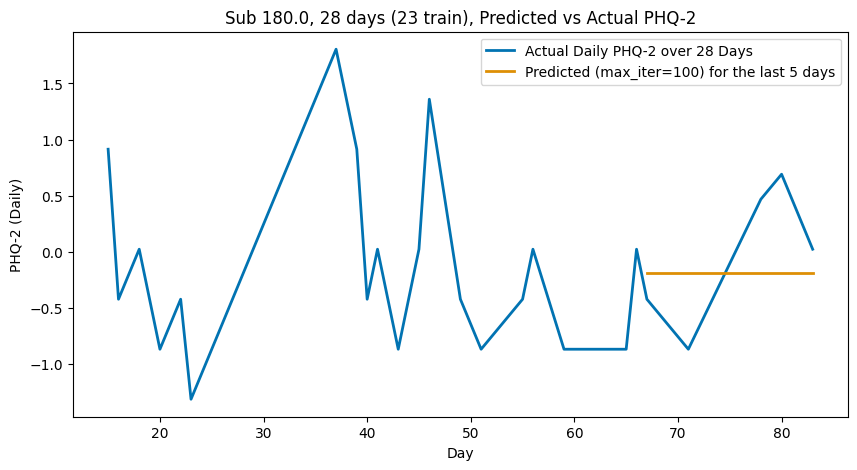

For 187.0, X-cols: ['hours_of_sleep_hr', 'hours_of_sleep_hr.2', 'hours_accounted_for', 'distance_walking_hr', 'hours_of_sleep_hr.1', 'hours_of_sleep_hr.3', 'distance_walking', 'hours_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation']


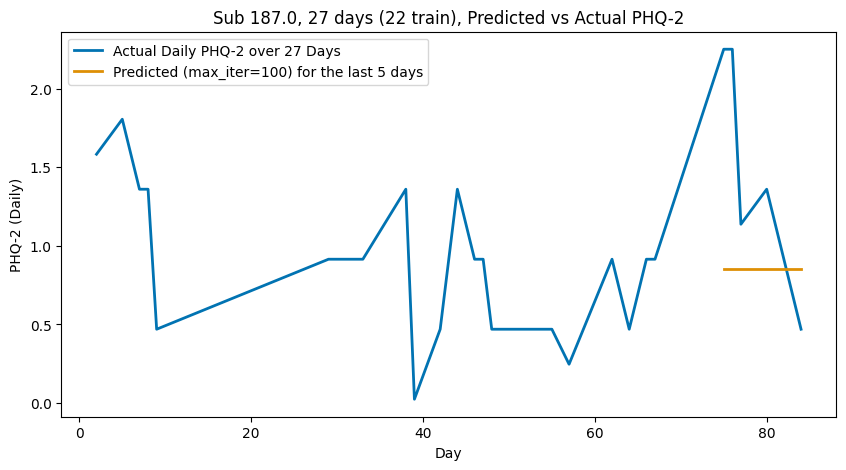

In [ ]:
import seaborn as sns
max_iter_list = [100]
colors = sns.color_palette("colorblind")

test_perc = 0.2

strong_corrs = {}
y_col = 'phq2_sum'
similar_y_col = 'phq'
for name in ['v1_day','v2_day']:
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	for sub, sub_df in df.groupby('num_id'):
		if sub=='1735.0' or sub==1735.0:
			continue
		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values('day', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			sub_count+=1
			corr_df = sub_df_clean.corr(numeric_only=True)[y_col].abs().sort_values(ascending=False)
			corr_df = pd.DataFrame(corr_df).reset_index(names=['column'])
			corr_df[y_col] = pd.to_numeric(corr_df[y_col])
			strong_corr = corr_df.where(corr_df[y_col] > 0.1).dropna(how='all')
			clean_corr = [col for col in strong_corr['column'].to_list() if col not in id_columns and 'Unnamed' not in col and 'indicator' not in col and col not in ['week','month','day']]
			strong_corrs[sub] = clean_corr
			X_cols = [col for col in strong_corrs[sub] if similar_y_col not in col]
			X = sub_df_clean[X_cols[:10]]

			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			train_days_for_graphing = sub_df_clean['day'][:train_num]
			test_days_for_graphing = sub_df_clean['day'][train_num:]



			# build your actual_df as before
			actual_df = pd.DataFrame({
				'day': sub_df_clean['day'],
				y_col: y
			})
			
			if sub_count<5:
				fig, ax = plt.subplots(figsize=(10, 5))
				actual_df.plot(
					x='day',
					y=y_col,
					color=colors[0],
					label=f"Actual Daily PHQ-2 over {days} Days",
					linewidth=2,
					ax=ax
				)

			for idx, max_iter in enumerate(max_iter_list):
				hgbt = HistGradientBoostingRegressor(max_iter=max_iter, random_state=42)
				hgbt.fit(X_train, y_train)
				y_pred = hgbt.predict(X_test)

				pred_df = pd.DataFrame({
					'day': test_days_for_graphing,
					y_col : y_pred
				})

				if sub_count<5:
					pred_df.plot(
						x = 'day',
						y = y_col,
						color=colors[idx + 1],
						label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
						linewidth=2,
						ax=ax,
					)


				
			
			if sub_count<5:
				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual PHQ-2",
					xlabel="Day",
					ylabel="PHQ-2 (Daily)",
				)
				print(f'For {sub}, X-cols: {X.columns.to_list()}')
				ax.legend()
				plt.show()

				
			


# Try doing by-subject top-10 ANOVA

Run on: Sun 12 Apr 2026, 11:16PM
For 1.0, X-cols: ['mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sleep_1', 'sds_1', 'stress', 'phq9_9_base', 'phq9_1_base', 'phq9_5_base', 'education', 'sleep_3', 'phq9_4_base', 'support', 'phq9_8_base', 'phq9_7_base', 'phq9_3_base', 'sds_3', 'income_satisfaction', 'phq9_2_base', 'phq9_6_base', 'sds_2', 'sleep_2', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq9_1', 'phq9_2', 'phq9_3', 'phq9_4', 'phq9_5', 'phq9_6', 'phq9_7', 'phq9_8', 'phq9_9', 'phq9_sum', 'Unnamed: 0', 'num_id', 'date', 'month', 'week', 'day', 'id_week', 'id_day', 'v', 'day_of_week', 'cohort_Akili', 'cohort_Health tips', 'cohort_PST', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_2.0', 'race_0.0', 'race_1.0', 'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0', 'race_6.0', 'season_fall', 'season_spring', 'season_summer', 'se

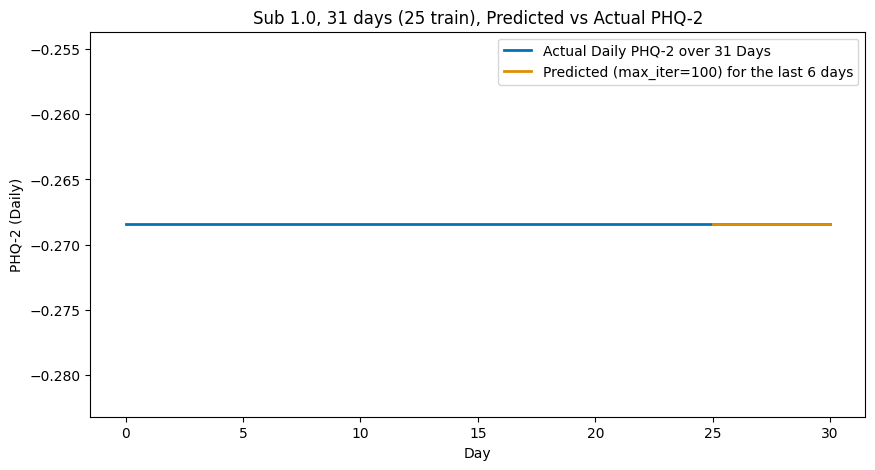

For 13.0, X-cols: ['missed_interactions', 'sleep_1', 'sleep_2', 'pc_unreturned_calls', 'sds_3', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'pc_sms', 'sms_length']


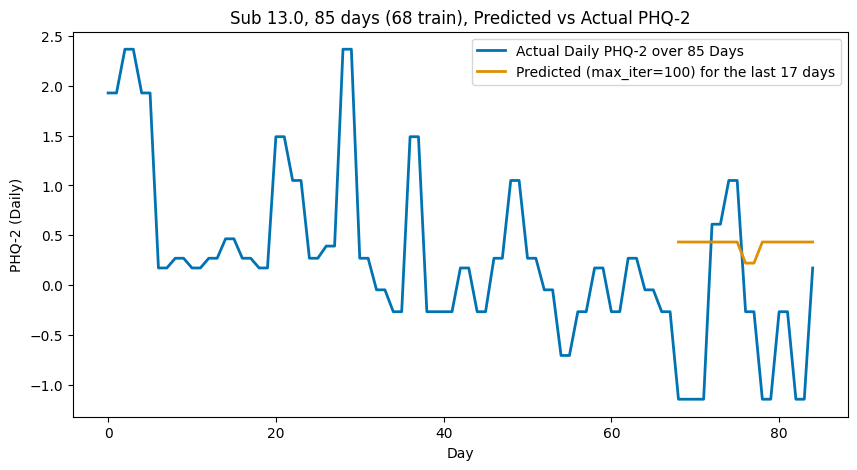

For 14.0, X-cols: ['sleep_2', 'sds_3', 'call_duration', 'pc_mobility', 'sds_2', 'mobility', 'pc_calls', 'mobility_radius', 'mood_1', 'sds_1']


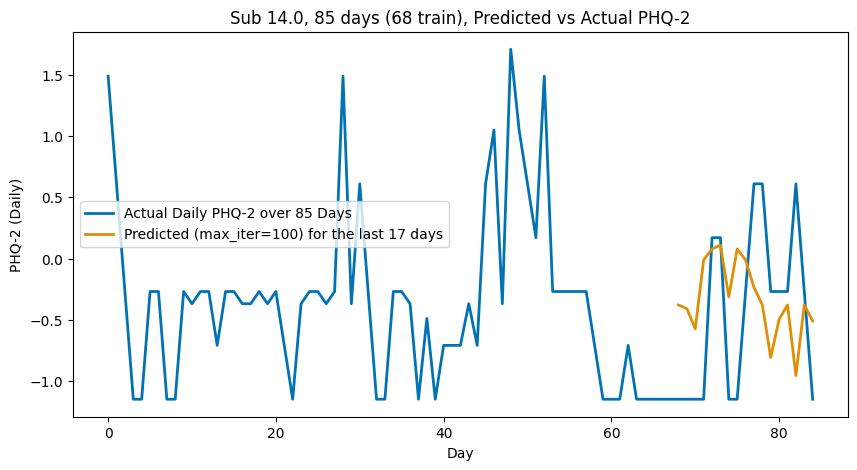

For 29.0, X-cols: ['stress', 'sds_1', 'sleep_2', 'sleep_3', 'sms_length', 'pc_sms', 'mobility_radius', 'call_count', 'pc_calls', 'pc_mobility']


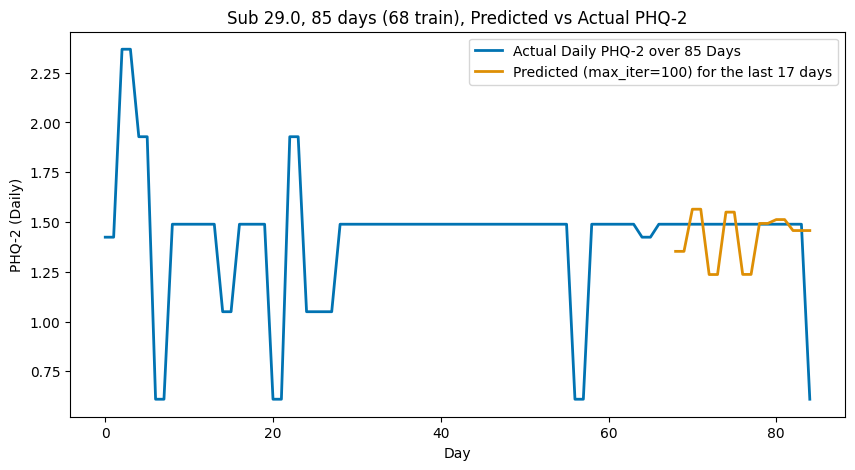

For 161.0, X-cols: ['precip_sum', 'hours_of_sleep_hr', 'hours_powered_vehicle', 'hours_powered_vehicle_hr', 'pc_weather_means', 'sleep_3', 'temp_IQR', 'mood_1', 'humidity_mean', 'dew_point_IQR']


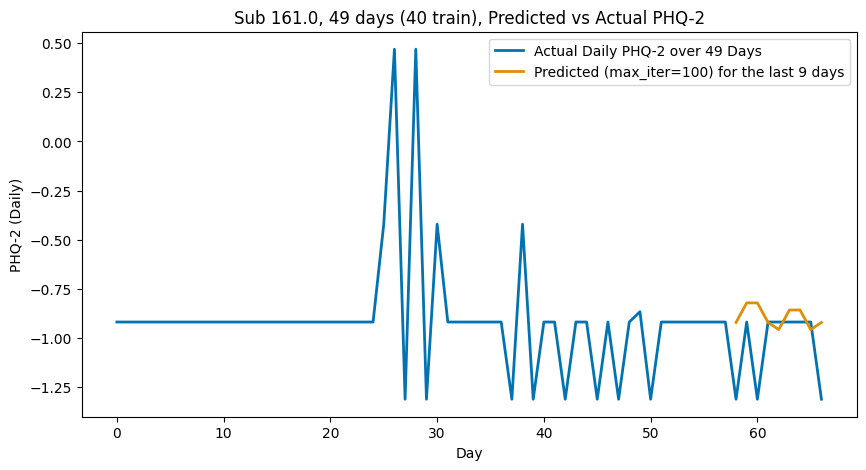

For 166.0, X-cols: ['dew_point_std', 'pc_dew_point', 'temp_mean', 'pc_temp_humidity_std', 'humidity_std', 'dew_point_mean', 'humidity_IQR', 'pc_dew_point_std', 'temp_median', 'dew_point_median']


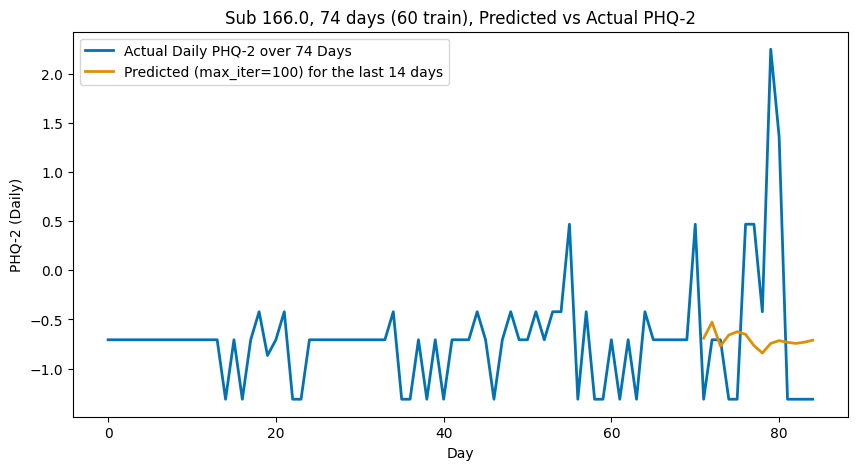

For 174.0, X-cols: ['humidity_IQR', 'temp_IQR', 'temp_median', 'pc_temp_humidity_std', 'hours_walking', 'pc_temp', 'temp_mean', 'hours_stationary', 'temp_std', 'humidity_std']


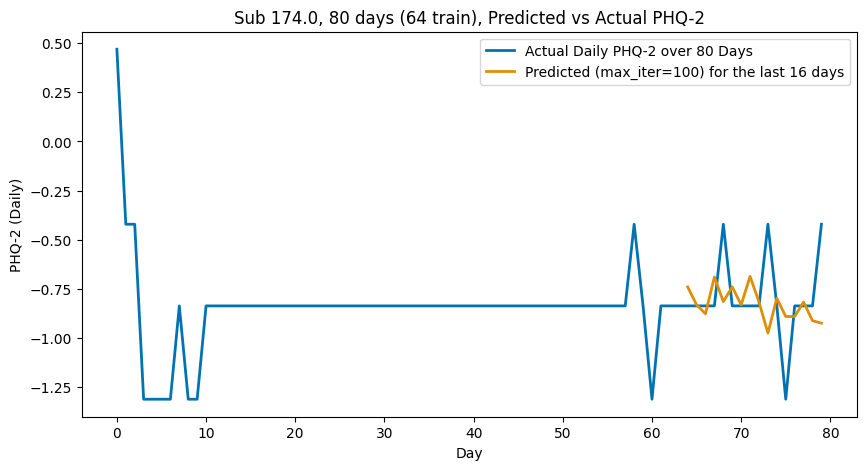

For 175.0, X-cols: ['location_variance_hr', 'hours_accounted_for', 'location_variance', 'mood_1', 'sds_3', 'sds_1', 'stress', 'sds_2', 'pc_weather_means', 'distance_powered_vehicle_hr']


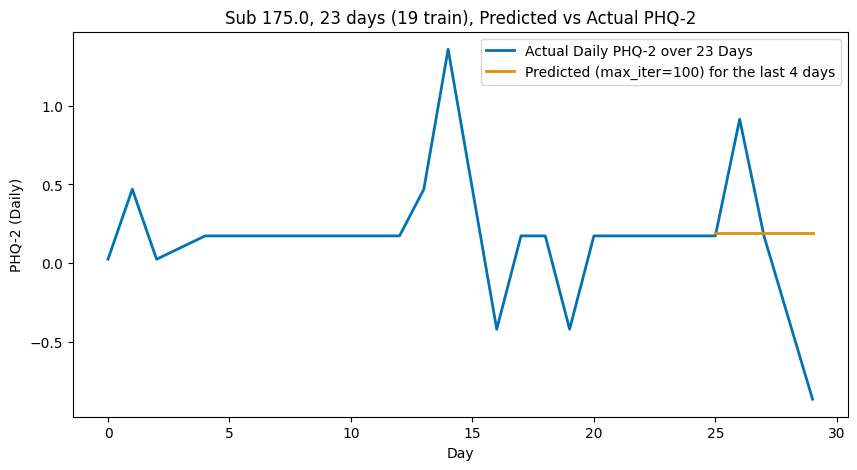

In [ ]:
import seaborn as sns
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")


test_perc = 0.2

strong_corrs = {}
y_col = 'phq2_sum'
similar_y_col = 'phq'
for name in ['v1_day','v2_day','v1_week','v2_week']:
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	for sub, sub_df in df.groupby('num_id'):
		if sub=='1735.0' or sub==1735.0:
			continue
		
		try:
			top_features_sub = top_features[y_col][name][sub]
		except Exception as e:
			pass

		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values('day', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			sub_count+=1
			X = sub_df_clean[top_features_sub]
			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			train_days_for_graphing = sub_df_clean['day'][:train_num]
			test_days_for_graphing = sub_df_clean['day'][train_num:]



			# build your actual_df as before
			actual_df = pd.DataFrame({
				'day': sub_df_clean['day'],
				y_col: y
			})
			
			if sub_count<5:
				fig, ax = plt.subplots(figsize=(10, 5))
				actual_df.plot(
					x='day',
					y=y_col,
					color=colors[0],
					label=f"Actual Daily PHQ-2 over {days} Days",
					linewidth=2,
					ax=ax
				)

			for idx, max_iter in enumerate(max_iter_list):
				hgbt = HistGradientBoostingRegressor(max_iter=max_iter_list[0], random_state=42)
				hgbt.fit(X_train, y_train)
				y_pred = hgbt.predict(X_test)

				pred_df = pd.DataFrame({
					'day': test_days_for_graphing,
					y_col : y_pred
				})

				if sub_count<5:
					pred_df.plot(
						x = 'day',
						y = y_col,
						color=colors[idx + 1],
						label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
						linewidth=2,
						ax=ax,
					)


				
			
			if sub_count<5:
				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual PHQ-2",
					xlabel="Day",
					ylabel="PHQ-2 (Daily)",
				)
				print(f'For {sub}, X-cols: {X.columns.to_list()}')
				ax.legend()
				plt.show()

				
			


# By subject PHQ2 using only top 15 ANOVA all-sub features for PHQ2

Run on: Sun 12 Apr 2026, 11:16PM
################### v1_day ###################
Using cols: ['mobility', 'mobility_radius', 'sms_count', 'aggregate_communication', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sds_1', 'stress', 'support', 'sds_3', 'sds_2', 'dt_mobility_v2', 'pc_mobility', 'pc_unreturned_calls', 'pc_sms']


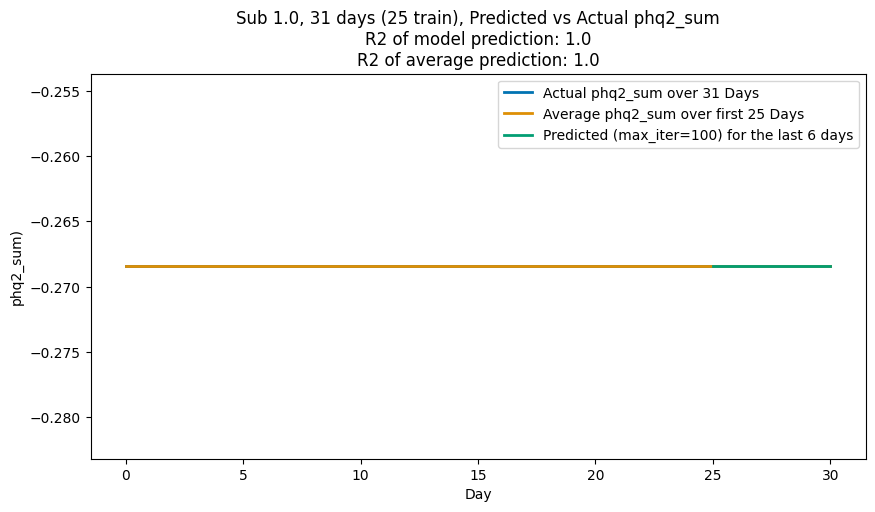

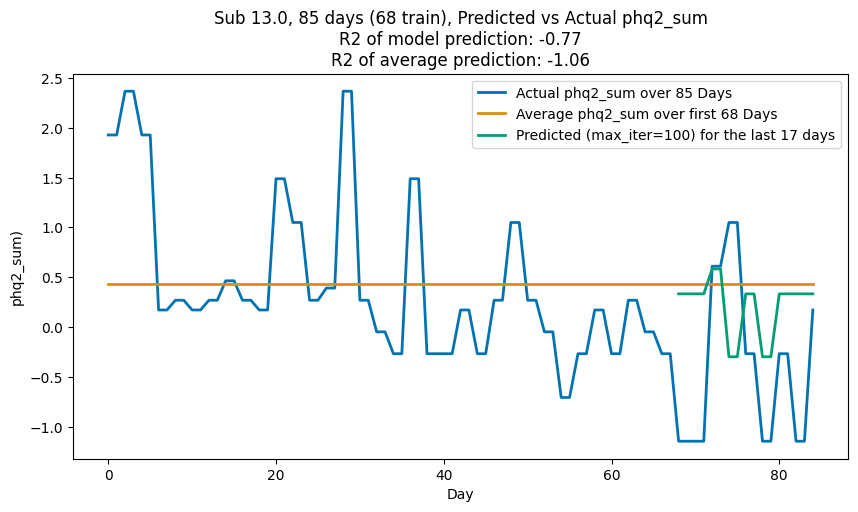

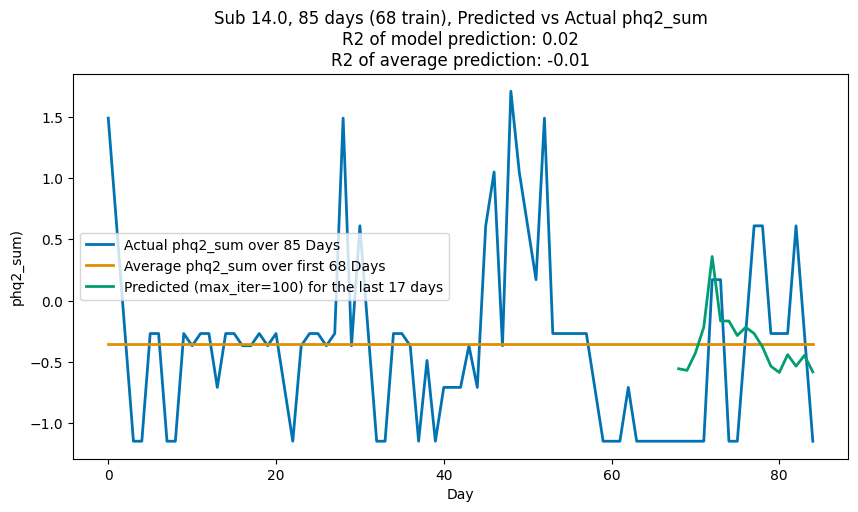

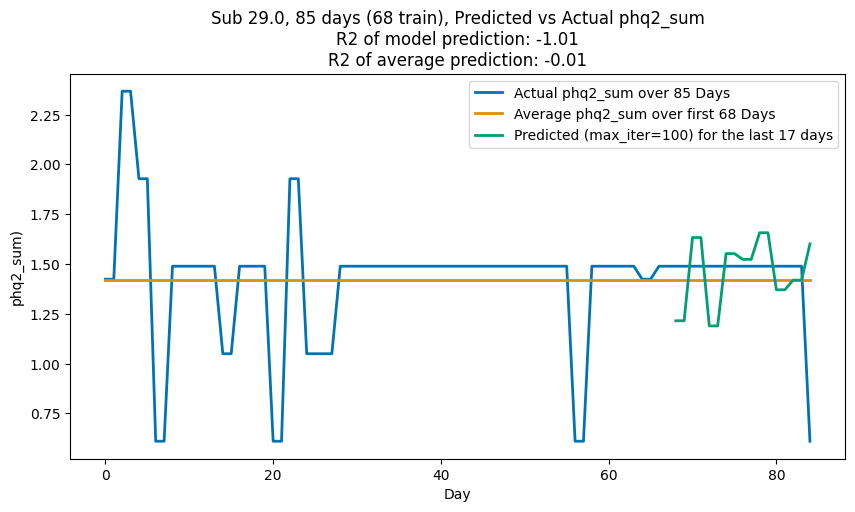

################### v2_day ###################
Using cols: ['distance_active_hr', 'location_variance_hr', 'location_variance', 'hours_active_hr', 'hours_of_sleep_hr', 'hours_of_sleep', 'humidity_IQR', 'humidity_std', 'temp_mean', 'temp_IQR', 'dew_point_mean', 'temp_median', 'hours_of_sleep_hr.1', 'hours_of_sleep_hr.2', 'hours_of_sleep_hr.3', 'pc_active_mobility', 'pc_temp_humidity_std', 'pc_dew_point_std', 'pc_temp']


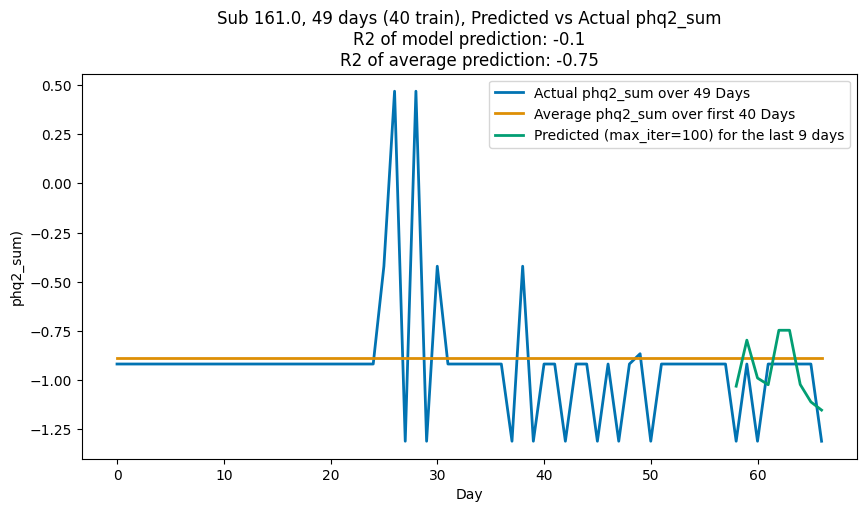

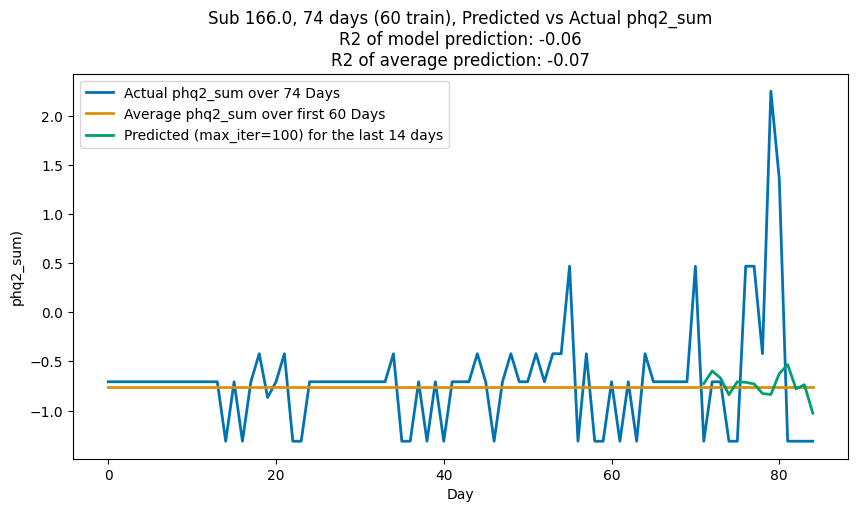

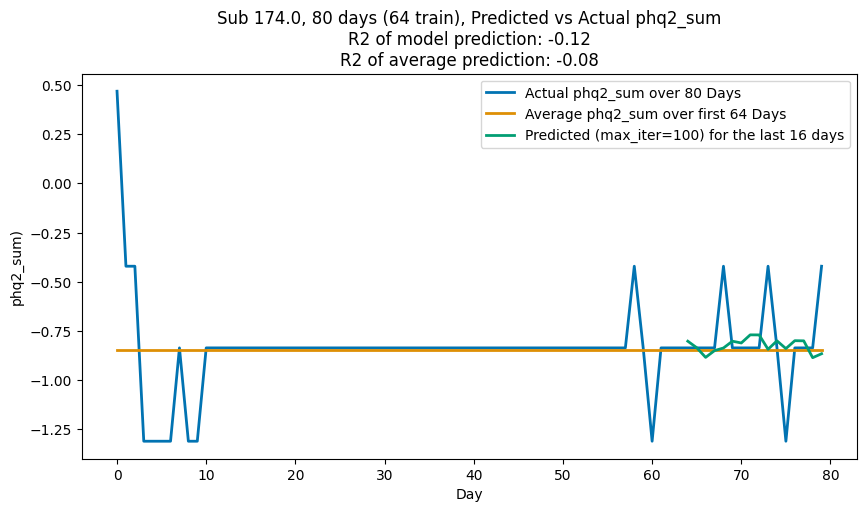

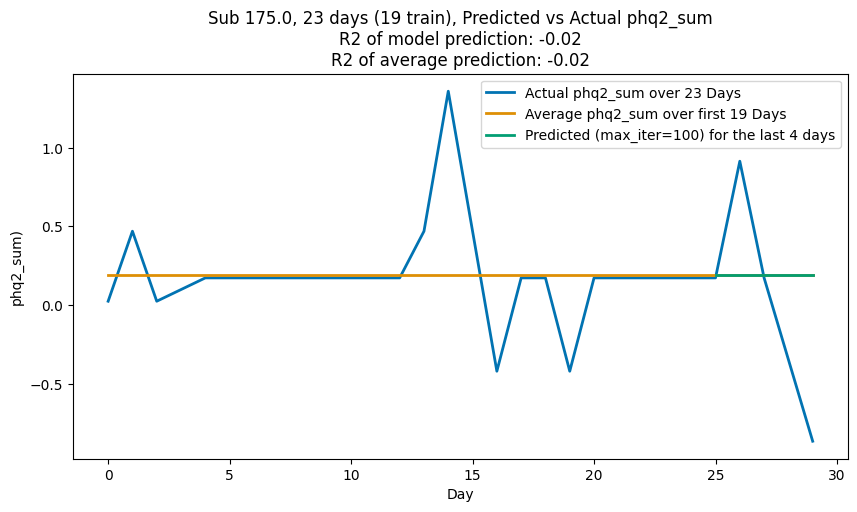

################### v1_week ###################
Using cols: ['mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sds_1', 'stress', 'support', 'sds_3', 'sds_2', 'dt_mobility_v2', 'pc_unreturned_calls', 'pc_mobility', 'pc_mobility_radius']
################### v2_week ###################
Using cols: ['hours_walking', 'distance_high_speed_transportation_hr', 'distance_active', 'distance_active_hr', 'hours_accounted_for', 'distance_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'distance_walking_hr', 'hours_of_sleep_hr', 'hours_of_sleep', 'hours_of_sleep_hr.1', 'hours_of_sleep_hr.2', 'hours_of_sleep_hr.3', 'sds_1', 'mood_1', 'support', 'sds_3', 'sds_2', 'pc_commute']


In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

test_perc = 0.2
r2_from_model = []

strong_corrs = {}
y_col = 'phq2_sum'
similar_y_col = 'phq'
for name in ['v1_day','v2_day','v1_week','v2_week']:
	print(f'################### {name} ###################')
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	X_choices = anova_features[y_col][name]
	X_cols = list(set([col for col in X_choices if similar_y_col not in col and 'Unnamed' not in col and col not in id_columns and 'indicator' not in col]))
	X_cols_present = [col for col in df.columns if any(item in col for item in X_cols)]
	print(f'Using cols: {X_cols_present}')
	for sub, sub_df in df.groupby('num_id'):
		sub_count+=1
		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values(by='day', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			X = sub_df_clean[X_cols_present]
			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			train_days_for_graphing = sub_df_clean['day'][:train_num]
			test_days_for_graphing = sub_df_clean['day'][train_num:]


			# build your actual_df as before
			actual_df = pd.DataFrame({
				'day': sub_df_clean['day'],
				y_col: y
			})
			

			
			avg = y_train.mean()
			avg_df = pd.DataFrame({
					'day': sub_df_clean['day'],
					y_col : [avg]*days
				})
			
			hgbt = HistGradientBoostingRegressor(max_iter=max_iter_list[0], random_state=42)
			hgbt.fit(X_train, y_train)
			y_pred = hgbt.predict(X_test)

			pred_df = pd.DataFrame({
				'day': test_days_for_graphing,
				y_col : y_pred
			})
			
			r2_actual_vs_model = safe_r2(y_test, pred_df[y_col])
			r2_actual_vs_avg = safe_r2(y_test, avg_df[y_col][:test_num])
			
			r2_from_model.append([sub, r2_actual_vs_model, r2_actual_vs_avg, r2_actual_vs_model-r2_actual_vs_avg])

			if sub_count<5:
				fig, ax = plt.subplots(figsize=(10, 5))


				actual_df.plot(
					x='day',
					y=y_col,
					color=colors[0],
					label=f"Actual {y_col} over {days} Days",
					linewidth=2,
					ax=ax
				)

				avg_df.plot(
					x='day',
					y=y_col,
					color=colors[1],
					label=f"Average {y_col} over first {train_num} Days",
					linewidth=2,
					ax=ax
				)

				pred_df.plot(
					x = 'day',
					y = y_col,
					color=colors[idx + 2],
					label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
					linewidth=2,
					ax=ax,
				)

				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual {y_col}\nR2 of model prediction: {round(r2_actual_vs_model,2)}\nR2 of average prediction: {round(r2_actual_vs_avg,2)}",
					xlabel="Day",
					ylabel=f"{y_col})",
				)
				ax.legend()
				plt.show()


	r2_from_model_df = pd.DataFrame(r2_from_model, columns=['sub', 'r2_actual_vs_model', 'r2_actual_vs_avg', 'r2_model_increase_from_avg'])
	r2_from_model_df.to_csv(os.path.join(results_dir, f'{name}_{y_col}_r2_modelANOVA15_increase_from_avg.csv'))
			
		


## PHQ2 from Top 10 LME features

Run on: Wed 27 May 2026, 05:20PM
################### v1_day ###################
Using cols: ['unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'income_lastyear', 'pc_unreturned_calls']


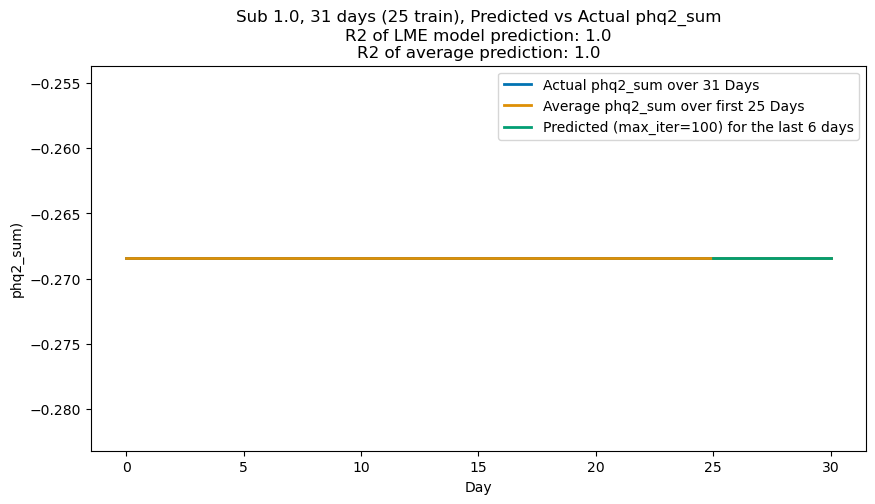

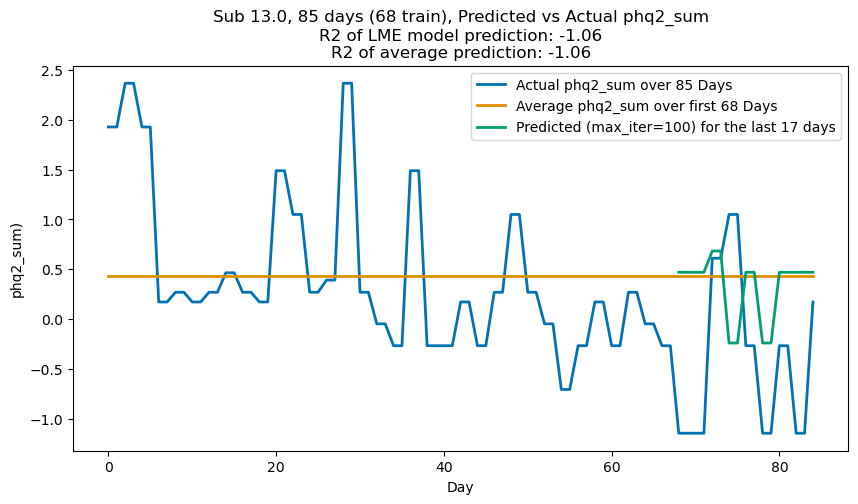

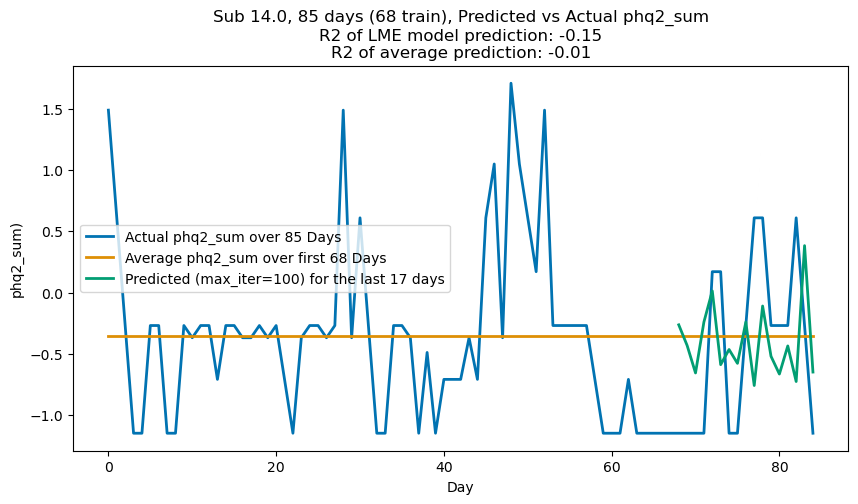

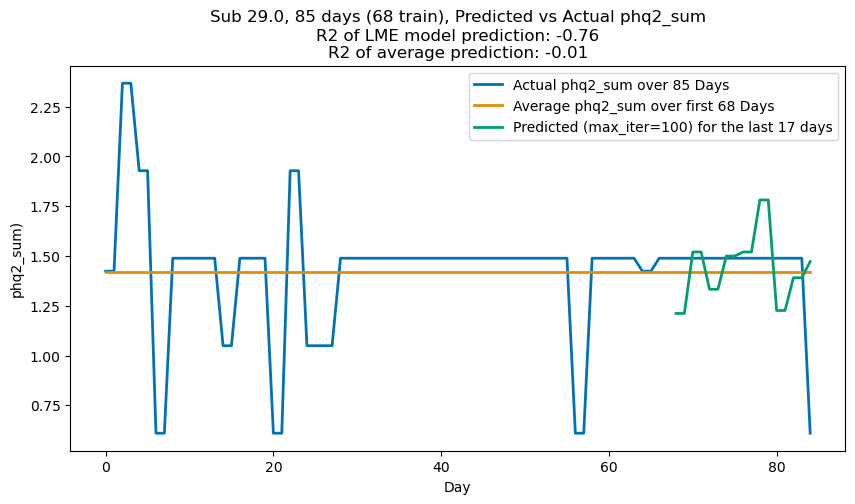

################### v2_day ###################
Using cols: ['hours_walking', 'distance_high_speed_transportation_hr', 'hours_accounted_for', 'location_variance_hr', 'distance_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'came_to_work', 'location_variance', 'hours_powered_vehicle_hr', 'distance_walking_hr', 'distance_high_speed_transportation', 'humidity_median', 'temp_median', 'temp_std', 'hours_stationary_nhw']


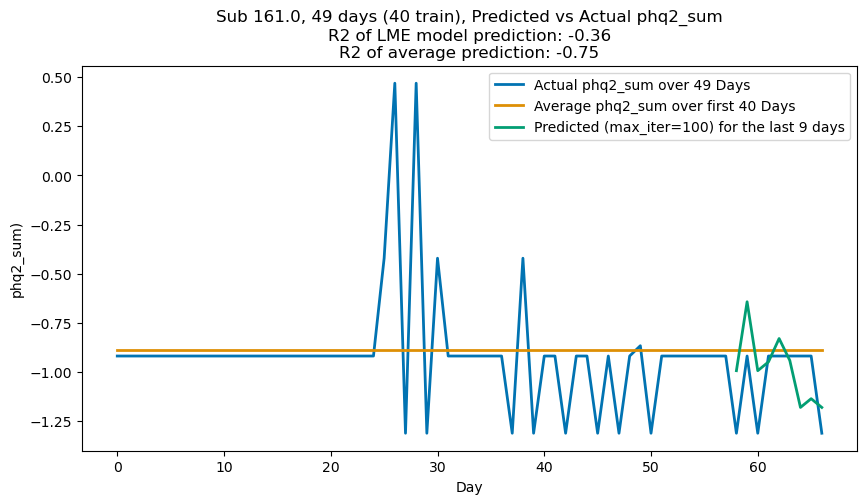

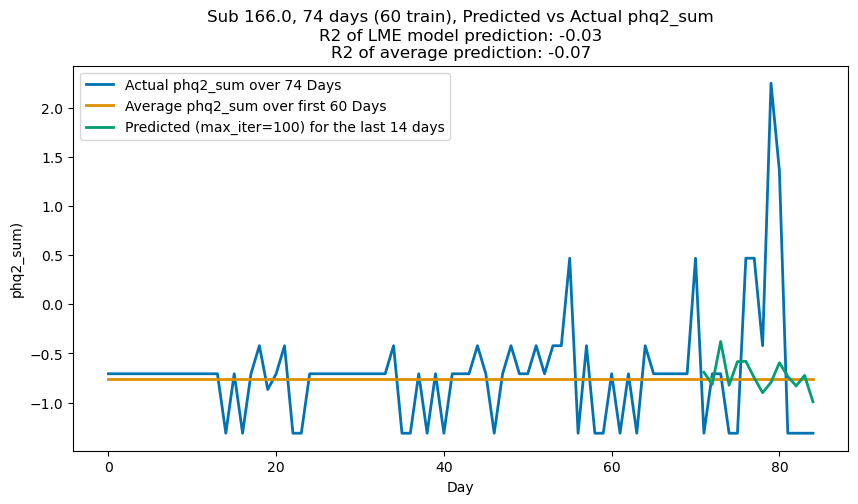

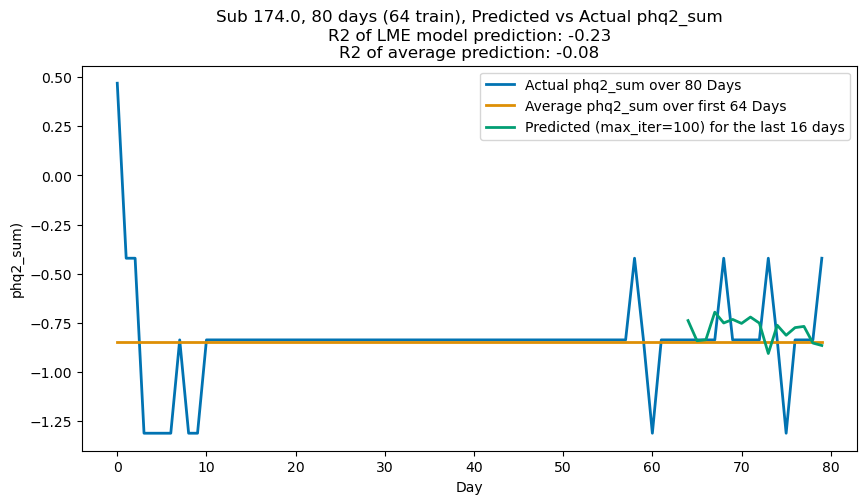

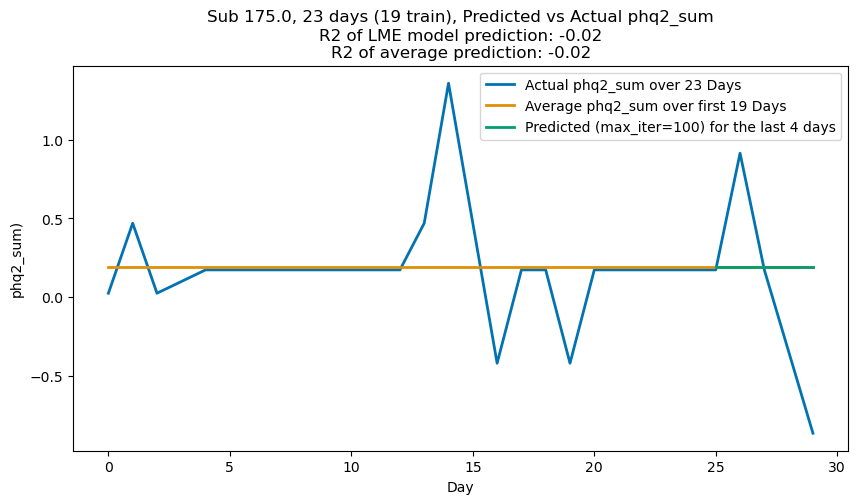

################### v1_week ###################
Using cols: ['mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'income_lastyear', 'pc_unreturned_calls', 'pc_mobility_radius']
################### v2_week ###################
Using cols: ['distance_high_speed_transportation_hr', 'location_variance_hr', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'location_variance', 'distance_walking_hr', 'distance_high_speed_transportation', 'humidity_median', 'dew_point_IQR', 'dew_point_std', 'temp_mean', 'humidity_mean', 'temp_IQR', 'temp_median', 'temp_std', 'hours_stationary_nhw', 'pc_dew_point_std']


In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

test_perc = 0.2
r2_from_model = []

strong_corrs = {}
y_col = 'phq2_sum'
similar_y_col = 'phq'
for name in ['v1_day','v2_day','v1_week','v2_week']:
	print(f'################### {name} ###################')
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	X_choices = lme_features[y_col][name]
	X_cols = list(set([col for col in X_choices if similar_y_col not in col and 'Unnamed' not in col and col not in id_columns and 'indicator' not in col]))
	X_cols_present = [col for col in df.columns if any(item in col for item in X_cols)]
	print(f'Using cols: {X_cols_present}')
	for sub, sub_df in df.groupby('num_id'):
		sub_count+=1
		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values(by='day', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			X = sub_df_clean[X_cols_present]
			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			train_days_for_graphing = sub_df_clean['day'][:train_num]
			test_days_for_graphing = sub_df_clean['day'][train_num:]


			# build your actual_df as before
			actual_df = pd.DataFrame({
				'day': sub_df_clean['day'],
				y_col: y
			})
			

			
			avg = y_train.mean()
			avg_df = pd.DataFrame({
					'day': sub_df_clean['day'],
					y_col : [avg]*days
				})
			max_iter=max_iter_list[0]
			hgbt = HistGradientBoostingRegressor(max_iter=max_iter, random_state=42)
			hgbt.fit(X_train, y_train)
			y_pred = hgbt.predict(X_test)

			pred_df = pd.DataFrame({
				'day': test_days_for_graphing,
				y_col : y_pred
			})
			
			r2_actual_vs_model = safe_r2(y_test, pred_df[y_col])
			r2_actual_vs_avg = safe_r2(y_test, avg_df[y_col][:test_num])
			
			r2_from_model.append([sub, r2_actual_vs_model, r2_actual_vs_avg, r2_actual_vs_model-r2_actual_vs_avg])

			if sub_count<5:
				fig, ax = plt.subplots(figsize=(10, 5))


				actual_df.plot(
					x='day',
					y=y_col,
					color=colors[0],
					label=f"Actual {y_col} over {days} Days",
					linewidth=2,
					ax=ax
				)

				avg_df.plot(
					x='day',
					y=y_col,
					color=colors[1],
					label=f"Average {y_col} over first {train_num} Days",
					linewidth=2,
					ax=ax
				)

				pred_df.plot(
					x = 'day',
					y = y_col,
					color=colors[0 + 2],
					label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
					linewidth=2,
					ax=ax,
				)

				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual {y_col}\nR2 of LME model prediction: {round(r2_actual_vs_model,2)}\nR2 of average prediction: {round(r2_actual_vs_avg,2)}",
					xlabel="Day",
					ylabel=f"{y_col})",
				)
				ax.legend()
				plt.show()


	r2_from_model_df = pd.DataFrame(r2_from_model, columns=['sub', 'r2_actual_vs_model', 'r2_actual_vs_avg', 'r2_model_increase_from_avg'])
	r2_from_model_df.to_csv(os.path.join(results_dir, f'{name}_{y_col}_r2_modelLME10_increase_from_avg.csv'))
			
		


# PHQ9 Using top 15 ANOVA

In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

max_iter_list = [100]
colors = sns.color_palette("colorblind")

test_perc = 0.2
r2_from_model = []

strong_corrs = {}
y_col = 'phq9_sum'
similar_y_col = 'phq9'
for name in ['v1_week','v2_week']:
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	X_choices = anova_features[y_col][name]
	X_cols = list(set([col for col in X_choices if similar_y_col not in col and 'Unnamed' not in col and col not in id_columns and 'indicator' not in col and col not in ['week','month','day']]))
	X_cols_present = [col for col in df.columns if any(item in col for item in X_cols)]
	print(f'Using cols: {X_cols_present}')
	for sub, sub_df in df.groupby('num_id'):
		sub_count+=1
		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values(by='week', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			X = sub_df_clean[X_cols_present]
			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			test_days_for_graphing = sub_df_clean['week'][train_num:]

			# build your actual_df as before
			actual_df = pd.DataFrame({
				'week': sub_df_clean['week'].copy(),
				y_col: y
			})
			

			
			avg = y_train.mean()
			avg_df = pd.DataFrame({
					'week': sub_df_clean['week'].copy(),
					y_col : [avg]*days
				})
			
			hgbt = HistGradientBoostingRegressor(max_iter=max_iter, random_state=42)
			hgbt.fit(X_train, y_train)
			y_pred = hgbt.predict(X_test)
			

			pred_df = pd.DataFrame({
				'week': test_days_for_graphing,
				y_col : y_pred
			})
			
			r2_actual_vs_model = safe_r2(y_test, pred_df[y_col])
			r2_actual_vs_avg = safe_r2(y_test, avg_df[y_col][:test_num])
			
			r2_from_model.append([sub, r2_actual_vs_model, r2_actual_vs_avg, r2_actual_vs_model-r2_actual_vs_avg])

			if sub_count<5:
				display(X_test)
				print(y_pred)
				fig, ax = plt.subplots(figsize=(10, 5))


				actual_df.plot(
					x='week',
					y=y_col,
					color=colors[0],
					label=f"Actual {y_col} over {days} Days",
					linewidth=2,
					ax=ax
				)

				avg_df.plot(
					x='week',
					y=y_col,
					color=colors[1],
					label=f"Average {y_col} over first {train_num} Days",
					linewidth=2,
					ax=ax
				)

				pred_df.plot(
					x = 'week',
					y = y_col,
					color=colors[idx + 2],
					label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
					linewidth=2,
					ax=ax,
				)

				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual {y_col}\nR2 of model prediction: {round(r2_actual_vs_model,2)}\nR2 of average prediction: {round(r2_actual_vs_avg,2)}",
					xlabel="Week",
					ylabel=f"{y_col})",
				)
				ax.legend()
				plt.show()


	r2_from_model_df = pd.DataFrame(r2_from_model, columns=['sub', 'r2_actual_vs_model', 'r2_actual_vs_avg', 'r2_model_increase_from_avg'])
	r2_from_model_df.to_csv(os.path.join(results_dir, f'{name}_{y_col}_15ANOVA_r2_model_increase_from_avg.csv'))
			
		


Run on: Tue 26 May 2026, 06:53PM
Using cols: ['mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq2_bin', 'dt_mobility_v2']
Using cols: ['distance_active', 'distance_active_hr', 'hours_accounted_for', 'humidity_median', 'dew_point_IQR', 'cloud_cover_IQR', 'dew_point_std', 'temp_mean', 'temp_IQR', 'temp_median', 'temp_std', 'phq2_1', 'phq2_2', 'phq2_sum', 'hours_stationary', 'hours_stationary_nhw']


## PHQ9 Using top 10 LME

In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
import seaborn as sns
max_iter_list = [100]
colors = sns.color_palette("colorblind")

test_perc = 0.2
r2_from_model = []

strong_corrs = {}
y_col = 'phq9_sum'
similar_y_col = 'phq9'
for name in ['v1_week','v2_week']:
	sub_count=0
	df=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	X_choices = lme_features[y_col][name]
	X_cols = list(set([col for col in X_choices if similar_y_col not in col and 'Unnamed' not in col and col not in id_columns and 'indicator' not in col and col not in ['week','month','day']]))
	X_cols_present = [col for col in df.columns if any(item in col for item in X_cols)]
	print(f'Using cols: {X_cols_present}')
	for sub, sub_df in df.groupby('num_id'):
		
		sub_df_clean = sub_df.dropna(subset=[y_col])
		sub_df_clean = sub_df_clean.sort_values(by='week', ascending=True)
		days = len(sub_df_clean)
		if days > 20:
			
			X = sub_df_clean[X_cols_present]
			y = sub_df_clean[y_col]
		
			test_num = int(days*test_perc)
			train_num = days - test_num
			X_train = X[:train_num]
			X_test = X[train_num:]
			y_train = y[:train_num]
			y_test = y[train_num:]

			test_days_for_graphing = sub_df_clean['week'][train_num:]

			# build your actual_df as before
			actual_df = pd.DataFrame({
				'week': sub_df_clean['week'].copy(),
				y_col: y
			})
			

			
			avg = y_train.mean()
			avg_df = pd.DataFrame({
					'week': sub_df_clean['week'].copy(),
					y_col : [avg]*days
				})
			
			hgbt = HistGradientBoostingRegressor(max_iter=max_iter, random_state=42)
			hgbt.fit(X_train, y_train)
			y_pred = hgbt.predict(X_test)
			

			pred_df = pd.DataFrame({
				'week': test_days_for_graphing,
				y_col : y_pred
			})
			
			r2_actual_vs_model = safe_r2(y_test, pred_df[y_col])
			r2_actual_vs_avg = safe_r2(y_test, avg_df[y_col][:test_num])
			
			r2_from_model.append([sub, r2_actual_vs_model, r2_actual_vs_avg, r2_actual_vs_model-r2_actual_vs_avg])

			if sub_count<5:
				#display(X_test)
				#print(y_pred)
				fig, ax = plt.subplots(figsize=(10, 5))


				actual_df.plot(
					x='week',
					y=y_col,
					color=colors[0],
					label=f"Actual {y_col} over {days} Days",
					linewidth=2,
					ax=ax
				)

				avg_df.plot(
					x='week',
					y=y_col,
					color=colors[1],
					label=f"Average {y_col} over first {train_num} Days",
					linewidth=2,
					ax=ax
				)

				pred_df.plot(
					x = 'week',
					y = y_col,
					color=colors[idx + 2],
					label=f"Predicted (max_iter={max_iter}) for the last {test_num} days",
					linewidth=2,
					ax=ax,
				)

				ax.set(
					title=f"Sub {sub}, {days} days ({train_num} train), Predicted vs Actual {y_col}\nR2 of model prediction: {round(r2_actual_vs_model,2)}\nR2 of average prediction: {round(r2_actual_vs_avg,2)}",
					xlabel="Week",
					ylabel=f"{y_col})",
				)
				ax.legend()
				plt.show()
				sub_count+=1


	r2_from_model_df = pd.DataFrame(r2_from_model, columns=['sub', 'r2_actual_vs_model', 'r2_actual_vs_avg', 'r2_model_increase_from_avg'])
	r2_from_model_df.to_csv(os.path.join(results_dir, f'{name}_{y_col}_LME10_r2_model_increase_from_avg.csv'))
			
		


Run on: Tue 26 May 2026, 06:50PM
LME features:  ['phq2_sum', 'phq2_1', 'phq2_2', 'phq2_bin', 'mobility_radius', 'unreturned_calls', 'missed_interactions', 'income_lastyear', 'call_count', 'sms_count', 'aggregate_communication', 'call_duration', 'sms_length', 'interaction_diversity']
Columns available ['hours_walking', 'hours_accounted_for', 'mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sleep_1', 'sds_1', 'stress', 'phq9_9_base', 'phq9_1_base', 'phq9_5_base', 'mood_1', 'education', 'sleep_3', 'phq9_4_base', 'support', 'phq9_8_base', 'phq9_7_base', 'phq9_3_base', 'sds_3', 'income_satisfaction', 'phq9_2_base', 'phq9_6_base', 'sds_2', 'sleep_2', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq9_1', 'phq9_2', 'phq9_3', 'phq9_4', 'phq9_5', 'phq9_6', 'phq9_7', 'phq9_8', 'phq9_9', 'phq9_sum', 'Unnamed: 0', 'num_id', 'date', 'month', 'week', 'day', 'id_week', 'v', 'day_

In [19]:
# Graph residuals
for model in ['ANOVA15','LME10']:
	for name in ['v1_day','v2_day','v1_week','v2_week']:
		r2_from_model_df=pd.read_csv(os.path.join(results_dir, f'{name}_phq2_sum_r2_model{model}_increase_from_avg.csv'))
		r2_from_model_df['r2_clipped'] = r2_from_model_df['r2_model_increase_from_avg'].clip(lower=-1)  # anything below -1 is "terrible"
		r2_from_model_df['r2_clipped2'] = r2_from_model_df['r2_clipped'].clip(upper=1)  # anything below -1 is "terrible"

		fig = px.histogram(r2_from_model_df,'r2_clipped2',title=f'R2 Model {model} PHQ-2 Prediction Increase from Subj-Average: {name}')
		fig.show()
	


## trying HistGradientBoosting on my data - all features 


In [21]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

y_cols = ['phq9_sum']
models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}
model_dict = {}
time_cols = ['month','week','day']

for name in ['v1_day','v2_day','v1_week','v2_week']:
	model_dict[name] = {}
	
	print(f'\n\n####### {name} #######')
	for y_col in y_cols:
		model_dict[name][y_col] = {}
		Xy_data=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))

		Xy=Xy_data.dropna(subset=[y_col])
		Xy=Xy.select_dtypes(include=('int64','float64'))

		baseline_cols_present = matches = [item for item in Xy.columns if any(col in item for col in baseline_cols)]
		y_cols_present = [item for item in Xy.columns if any(col in item for col in y_cols) or 'phq9' in item]
		drop_cols = [item for item in Xy.columns if 'Unnamed' in item or '_nan' in item or '_indicator' in item or 'season' in item or 'dt' in item or 'day' in item or 'week' in item or 'month' in item or 'date' in item]

		for time in ['baseline','8wks','both']:
			print(f'\n{time.upper()}')
			model_dict[name][y_col][time] = {}
			if 'baseline' in time:
				X=Xy[['num_id']+time_cols+baseline_cols_present].copy()
			elif '8wks' in time:
				X = Xy.drop(columns=[col for col in baseline_cols_present+y_cols_present+drop_cols if col not in id_columns]).copy()
			else:
				X=Xy.drop(columns=[col for col in y_cols_present+drop_cols if col not in id_columns])
			
			y=Xy[y_col]
			print('Columns in X:',X.columns.to_list())

			# Inputs
			groups = Xy['num_id']
			gkf = GroupKFold(n_splits=5)
			count=0
			print(f'X has {X.shape[0]} observations, {X.shape[1]} features')


			# print('models...')
			for model_name in models:
				model_dict[name][y_col][time][model_name] = {}
				model_dict[name][y_col][time][model_name]['model']=[]
				model_dict[name][y_col][time][model_name]['X_test']=[]
				model_dict[name][y_col][time][model_name]['r2_scores']=[]
				model_dict[name][y_col][time][model_name]['mae_scores']=[]
				model_dict[name][y_col][time][model_name]['y_pred']=[]
				model_dict[name][y_col][time][model_name]['y_test']=[]
				model_dict[name][y_col][time][model_name]['y_val']=[]
				model_dict[name][y_col][time][model_name]['y_valpred']=[]

				for train_idx, test_idx in gkf.split(X, y, groups):
					X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
					y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
					model_dict[name][y_col][time][model_name]['y_test'].append(y_test)
					model_dict[name][y_col][time][model_name]['X_test'].append(X_test)

					model = models[model_name][0]
					if y_col in ['change_cat','change_binary']:
						model= models[model_name][1]
					
					X_train_for_model = X_train.drop(columns=[col for col in time_cols+id_columns if col in X_train.columns and col != 'num_id'])
					if count==0:
						print(f'First CV\n{len(X_train)} observations in X_train, {len(X_test)} in X_test. {X_train['num_id'].nunique()} train subs, {X_test['num_id'].nunique()} test subs')
						print(f'Features: {X_train_for_model.columns.to_list()}')
						print(f'Train Subjects: {set(list(X_train['num_id']))}')
						print(f'Train Subjects: {set(list(X_test['num_id']))}')
						if len(set(list(X_train['num_id'])+list(X_test['num_id']))) == len(set(list(X_train['num_id']))) + len(set(list(X_test['num_id']))):
							print(f'All subjects in each set are unique')
						else:
							print(f"Overlapping subjects")
						count=1


					model.fit(X_train_for_model, y_train)
					assert list(model.feature_names_in_) == list(X_train_for_model.columns), f"Feature mismatch before saving model for {time}"
					model_dict[name][y_col][time][model_name]['model'].append(model)
					
					X_test_for_model = X_test.drop(columns=[col for col in time_cols+id_columns if col in X_train.columns and col != 'num_id'])
					y_pred = model.predict(X_test_for_model)
					model_dict[name][y_col][time][model_name]['y_pred'].append(y_pred)

					

					r2 = r2_score(y_test, y_pred)
					model_dict[name][y_col][time][model_name]['r2_scores'].append(r2)

					mae = mean_absolute_error(y_test, y_pred)
					model_dict[name][y_col][time][model_name]['mae_scores'].append(mae)
					

				print(f"{y_col} from {time} -- mean R²: {round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict[name][y_col][time][model_name]['mae_scores']), 4)} of scores [{round(y.min(), 1)}-{round(y.max(), 1)}]")
				

Run on: Wed 27 May 2026, 10:40PM


####### v1_day #######

BASELINE
Columns in X: ['num_id', 'month', 'week', 'day', 'phq9_9_base', 'phq9_1_base', 'phq9_5_base', 'education', 'phq9_4_base', 'phq9_8_base', 'phq9_7_base', 'phq9_3_base', 'income_satisfaction', 'phq9_2_base', 'phq9_6_base', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_2.0', 'race_0.0', 'race_1.0', 'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0', 'race_6.0', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'bin_clin', 'working', 'age_category']
X has 5556 observations, 34 features
First CV
4444 observations in X_train, 1112 in X_test. 143 train subs, 36 test subs
Features: ['num_id', 'phq9_9_base', 'phq9_1_base', 'phq9_5_base', 'education', 'phq9_4_base', 'phq9_8_base', 'phq9_7_base', 'phq9_3_base', 'income_satisfaction', 'phq9_2_base', 'phq9_6_base', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_2.0', 'race_0.0', 'race_1.0', 'race_2.0', 'rac

## Histgradient predicting PHQ9_sum but with only top 15 all-subject ANOVA features

In [31]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

y_cols = ['phq9_sum','phq2_sum']
models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}
time = 'anova_15'


for name in ['v1_week','v2_week']:
	print(f'\n\n####### {name} #######')
	for y_col in y_cols:
		if not y_col in model_dict[name]:
			model_dict[name][y_col]={}

		model_dict[name][y_col][time] = {}
		Xy=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))

		Xy=Xy.dropna(subset=[y_col])
		X_choices = anova_features[y_col][name]
		X = Xy[[col for col in id_columns+X_choices if col in Xy.columns]]
		print('Columns in X:',X.columns.to_list())
		y = Xy[y_col]

		# Inputs
		groups = Xy['num_id']
		gkf = GroupKFold(n_splits=5)
		count=0
		print(f'X has {X.shape[0]} observations, {X.shape[1]} features')


		# print('models...')
		for model_name in models:
			model_dict[name][y_col][time][model_name] = {}
			model_dict[name][y_col][time][model_name]['model']=[]
			model_dict[name][y_col][time][model_name]['X_test']=[]
			model_dict[name][y_col][time][model_name]['r2_scores']=[]
			model_dict[name][y_col][time][model_name]['mae_scores']=[]
			model_dict[name][y_col][time][model_name]['y_pred']=[]
			model_dict[name][y_col][time][model_name]['y_test']=[]
			model_dict[name][y_col][time][model_name]['y_val']=[]
			model_dict[name][y_col][time][model_name]['y_valpred']=[]
			for train_idx, test_idx in gkf.split(X, y, groups):
				X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
				y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
				model_dict[name][y_col][time][model_name]['y_test'].append(y_test)
				model_dict[name][y_col][time][model_name]['X_test'].append(X_test)

				model = models[model_name][0]
				if y_col in ['change_cat','change_binary']:
					model= models[model_name][1]
				
				X_train_for_model = X_train.drop(columns=[col for col in id_columns if col in X_train.columns])
				if count==0:
					print(f'First CV\n{len(X_train)} observations in X_train, {len(X_test)} in X_test. {X_train['num_id'].nunique()} train subs, {X_test['num_id'].nunique()} test subs')
					print(f'Features: {X_train_for_model.columns.to_list()}')
					print(f'Train Subjects: {set(list(X_train['num_id']))}')
					print(f'Train Subjects: {set(list(X_test['num_id']))}')
					if len(set(list(X_train['num_id'])+list(X_test['num_id']))) == len(set(list(X_train['num_id']))) + len(set(list(X_test['num_id']))):
						print(f'All subjects in each set are unique')
					else:
						print(f"Overlapping subjects")
					count=1


				model.fit(X_train_for_model, y_train)
				assert list(model.feature_names_in_) == list(X_train_for_model.columns), f"Feature mismatch before saving model for {time}"
				model_dict[name][y_col][time][model_name]['model'].append(model)
				
				X_test_for_model = X_test.drop(columns=[col for col in time_cols+id_columns if col in X_test.columns])
				y_pred = model.predict(X_test_for_model)
				model_dict[name][y_col][time][model_name]['y_pred'].append(y_pred)

				

				r2 = r2_score(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['r2_scores'].append(r2)

				mae = mean_absolute_error(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['mae_scores'].append(mae)
				

				print(f"{y_col} from {time} -- mean R²: {round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict[name][y_col][time][model_name]['mae_scores']), 4)} of scores [{round(y.min(), 1)}-{round(y.max(), 1)}]")
				





Run on: Wed 27 May 2026, 11:04PM


####### v1_week #######
Columns in X: ['num_id', 'date', 'month', 'week', 'day', 'id_week', 'v', 'day_of_week', 'interaction_diversity', 'phq2_1', 'missed_interactions', 'aggregate_communication', 'sms_length', 'phq2_sum', 'call_duration', 'sms_count', 'call_count', 'unreturned_calls', 'phq2_2', 'phq2_bin', 'mobility', 'mobility_radius']
X has 907 observations, 22 features
First CV
725 observations in X_train, 182 in X_test. 139 train subs, 35 test subs
Features: ['interaction_diversity', 'phq2_1', 'missed_interactions', 'aggregate_communication', 'sms_length', 'phq2_sum', 'call_duration', 'sms_count', 'call_count', 'unreturned_calls', 'phq2_2', 'phq2_bin', 'mobility', 'mobility_radius']
Train Subjects: {13.0, 14.0, 17.0, 44.0, 60.0, 71.0, 73.0, 1117.0, 94.0, 105.0, 108.0, 1132.0, 1136.0, 1158.0, 135.0, 1166.0, 1687.0, 1692.0, 1693.0, 1697.0, 1700.0, 1704.0, 1707.0, 1710.0, 1202.0, 1715.0, 1204.0, 1717.0, 1719.0, 1721.0, 1724.0, 1726.0, 1727.0, 1728.0

In [32]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

y_cols = ['phq9_sum','phq2_sum']
models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}
time = 'lme_10'


for name in ['v1_day','v2_day','v1_week','v2_week']:
	print(f'\n\n####### {name} #######')
	for y_col in y_cols:
		if not y_col in model_dict[name]:
			model_dict[name][y_col]={}

		model_dict[name][y_col][time] = {}
		Xy=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))

		Xy=Xy.dropna(subset=[y_col])
		X_choices = lme_features[y_col][name]
		X = Xy[[col for col in id_columns+X_choices if col in Xy.columns]]
		print('Columns in X:',X.columns.to_list())
		y = Xy[y_col]

		# Inputs
		groups = Xy['num_id']
		gkf = GroupKFold(n_splits=5)
		count=0
		print(f'X has {X.shape[0]} observations, {X.shape[1]} features')


		# print('models...')
		for model_name in models:
			model_dict[name][y_col][time][model_name] = {}
			model_dict[name][y_col][time][model_name]['model']=[]
			model_dict[name][y_col][time][model_name]['X_test']=[]
			model_dict[name][y_col][time][model_name]['r2_scores']=[]
			model_dict[name][y_col][time][model_name]['mae_scores']=[]
			model_dict[name][y_col][time][model_name]['y_pred']=[]
			model_dict[name][y_col][time][model_name]['y_test']=[]
			model_dict[name][y_col][time][model_name]['y_val']=[]
			model_dict[name][y_col][time][model_name]['y_valpred']=[]
			for train_idx, test_idx in gkf.split(X, y, groups):
				X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
				y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
				model_dict[name][y_col][time][model_name]['y_test'].append(y_test)
				model_dict[name][y_col][time][model_name]['X_test'].append(X_test)

				model = models[model_name][0]
				if y_col in ['change_cat','change_binary']:
					model= models[model_name][1]
				
				X_train_for_model = X_train.drop(columns=[col for col in id_columns if col in X_train.columns])
				if count==0:
					print(f'First CV\n{len(X_train)} observations in X_train, {len(X_test)} in X_test. {X_train['num_id'].nunique()} train subs, {X_test['num_id'].nunique()} test subs')
					print(f'Features: {X_train_for_model.columns.to_list()}')
					print(f'Train Subjects: {set(list(X_train['num_id']))}')
					print(f'Train Subjects: {set(list(X_test['num_id']))}')
					if len(set(list(X_train['num_id'])+list(X_test['num_id']))) == len(set(list(X_train['num_id']))) + len(set(list(X_test['num_id']))):
						print(f'All subjects in each set are unique')
					else:
						print(f"Overlapping subjects")
					count=1


				model.fit(X_train_for_model, y_train)
				assert list(model.feature_names_in_) == list(X_train_for_model.columns), f"Feature mismatch before saving model for {time}"
				model_dict[name][y_col][time][model_name]['model'].append(model)
				
				X_test_for_model = X_test.drop(columns=[col for col in time_cols+id_columns if col in X_test.columns])
				y_pred = model.predict(X_test_for_model)
				model_dict[name][y_col][time][model_name]['y_pred'].append(y_pred)

				

				r2 = safe_r2(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['r2_scores'].append(r2)

				mae = mean_absolute_error(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['mae_scores'].append(mae)
				

				print(f"{y_col} from {time} -- mean R²: {round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict[name][y_col][time][model_name]['mae_scores']), 4)} of scores [{round(y.min(), 1)}-{round(y.max(), 1)}]")
				





Run on: Wed 27 May 2026, 11:05PM


####### v1_day #######
Columns in X: ['num_id', 'date', 'month', 'week', 'day', 'id_week', 'id_day', 'v', 'day_of_week', 'missed_interactions', 'unreturned_calls', 'phq2_bin', 'call_count', 'interaction_diversity', 'aggregate_communication', 'phq2_sum', 'phq2_1', 'sms_count', 'phq2_2', 'sms_length', 'call_duration', 'income_lastyear']
X has 5556 observations, 22 features
First CV
4444 observations in X_train, 1112 in X_test. 143 train subs, 36 test subs
Features: ['missed_interactions', 'unreturned_calls', 'phq2_bin', 'call_count', 'interaction_diversity', 'aggregate_communication', 'phq2_sum', 'phq2_1', 'sms_count', 'phq2_2', 'sms_length', 'call_duration', 'income_lastyear']
Train Subjects: {13.0, 14.0, 17.0, 29.0, 71.0, 73.0, 1117.0, 94.0, 95.0, 105.0, 1132.0, 1136.0, 127.0, 1158.0, 140.0, 1173.0, 1687.0, 1688.0, 1692.0, 1701.0, 1191.0, 1704.0, 1707.0, 1708.0, 1710.0, 1712.0, 1202.0, 1203.0, 1715.0, 1716.0, 1718.0, 1207.0, 1725.0, 1726.0, 1732.0, 17

# SHAP for the above predictive models

Predicting phq9_sum in v1_week, columns: 8wks, model: HistGradientBoostingRegressor: Mean R2: 0.491


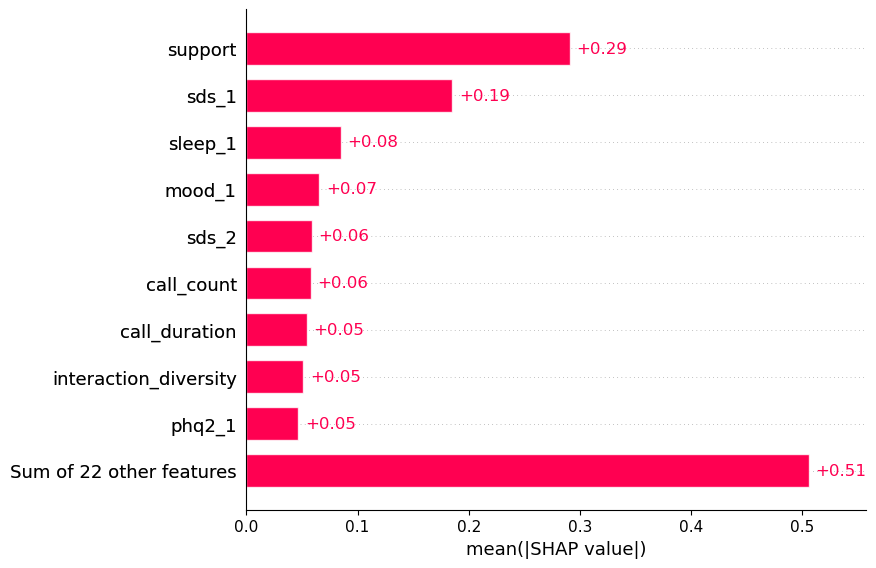

Predicting phq9_sum in v1_week, columns: both, model: HistGradientBoostingRegressor: Mean R2: 0.487


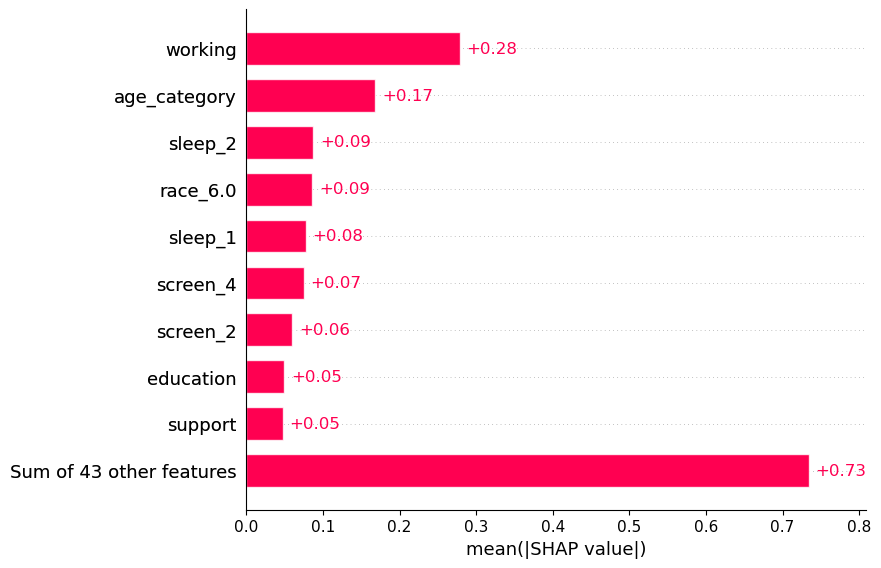

Predicting phq9_sum in v1_week, columns: anova_15, model: HistGradientBoostingRegressor: Mean R2: 0.261


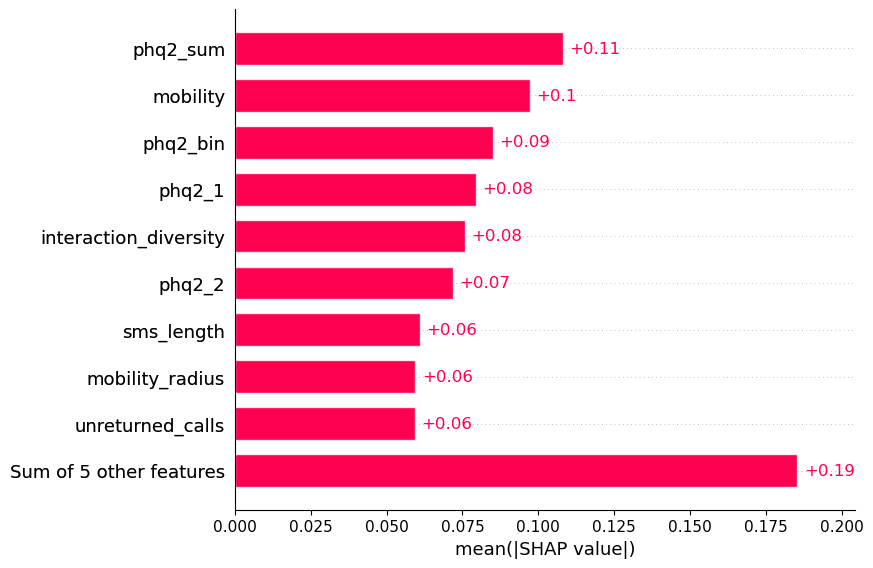

Predicting phq2_sum in v1_week, columns: anova_15, model: HistGradientBoostingRegressor: Mean R2: -0.244


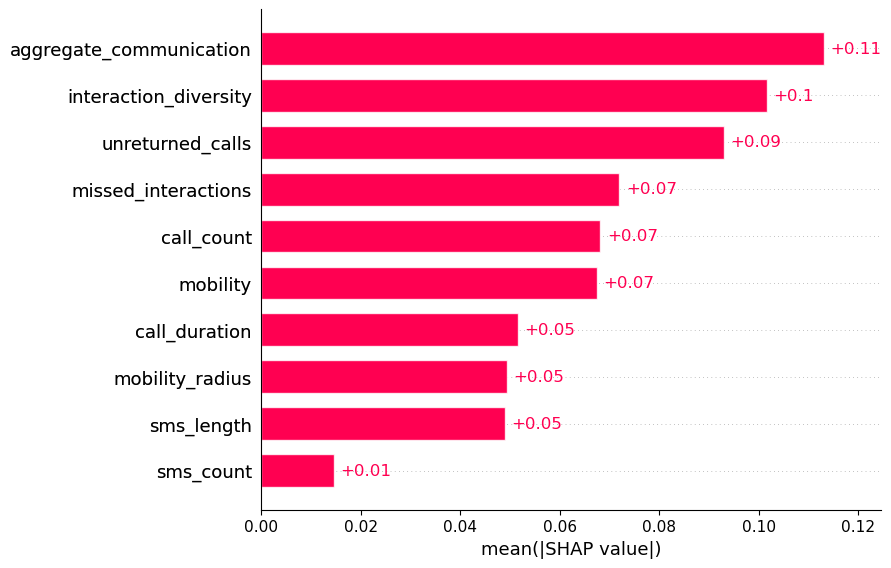

Predicting phq9_sum in v2_week, columns: 8wks, model: HistGradientBoostingRegressor: Mean R2: 0.395


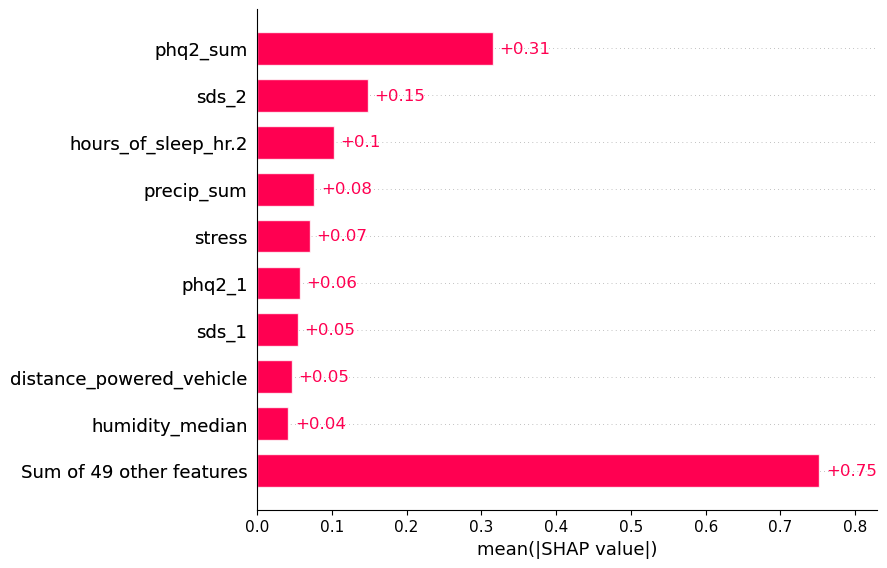

Predicting phq9_sum in v2_week, columns: both, model: HistGradientBoostingRegressor: Mean R2: 0.429


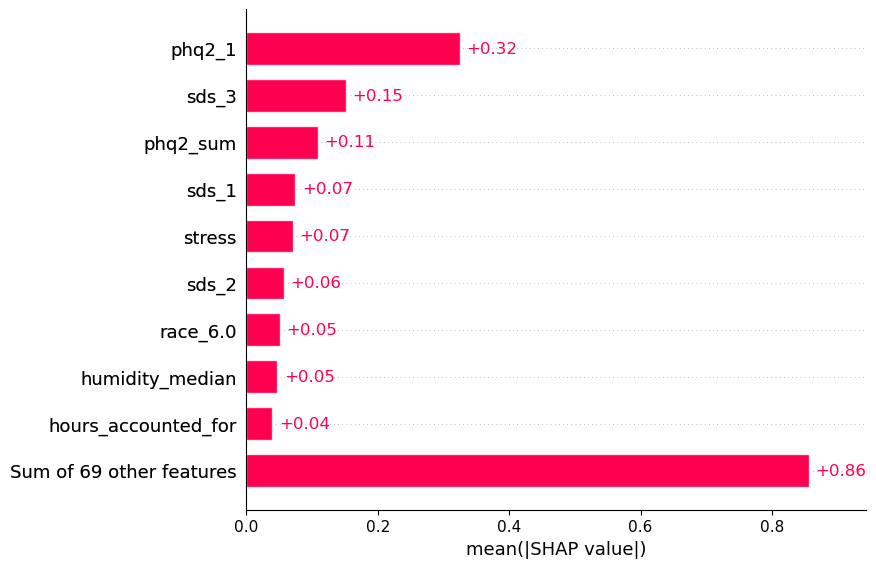

Predicting phq9_sum in v2_week, columns: anova_15, model: HistGradientBoostingRegressor: Mean R2: 0.211


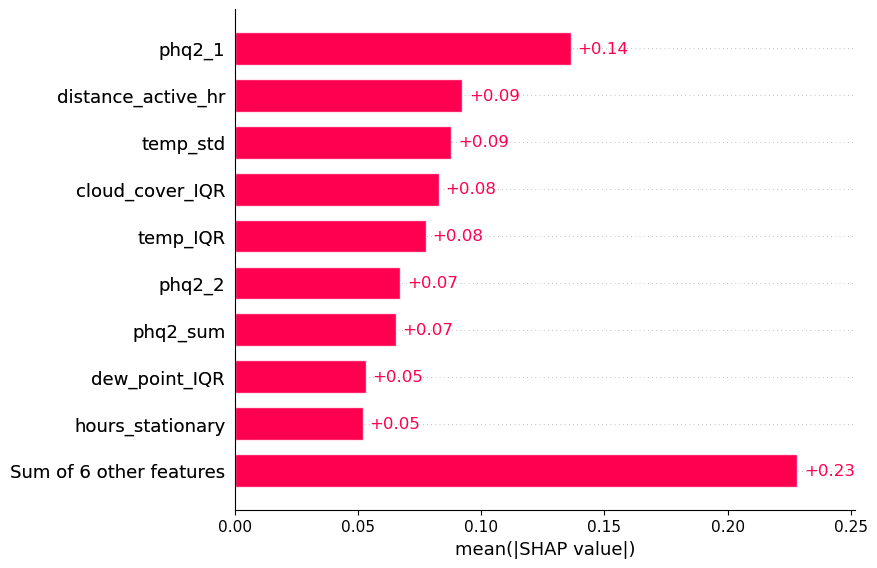

Predicting phq2_sum in v2_week, columns: anova_15, model: HistGradientBoostingRegressor: Mean R2: -0.27


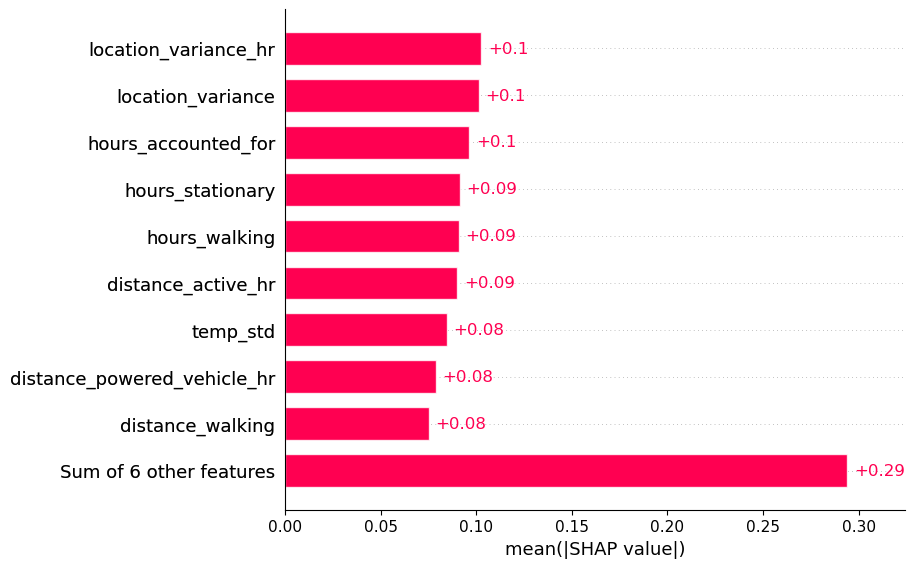

In [34]:
# SHAP Printing -- do after above, can't run without first making results {}
import gc 
import shap

for name in ['v1_week', 'v2_week']: #4
	for y_col in ['phq9_sum','phq2_sum']: #2
		for time in ['8wks','both','anova_15', 'lme10']:
			if not time in model_dict[name][y_col]:
				continue
			for model_name in models: #only one atm 
				mean_r2 = round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 3)
				print(f'Predicting {y_col} in {name}, columns: {time}, model: {model_name}: Mean R2: {mean_r2}')
				i=0 #change based on which CV you want to see
				df = model_dict[name][y_col][time][model_name]['X_test'][i]
				df_model = df[[col for col in df.columns if col not in id_columns]]
				explainer = shap.Explainer(model_dict[name][y_col][time][model_name]['model'][i], approximate=True)
				shap_values = explainer(df_model, check_additivity=False)
				shap.plots.bar(shap_values)
				del explainer, shap_values
				gc.collect()


In [37]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

import gc 
num_to_show=2

for name in ['v1_week', 'v2_week']: #4
	for y_col in ['phq9_sum','phq2_sum']: #2
		for time in ['8wks','both','anova_15', 'lme10']:
			for model_name in models: #only one atm 
				num_shown=0
				mean_r2 = round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 3)
				print(f'Predicting {y_col} in {name}, columns: {time}, model: {model_name}: Mean R2: {mean_r2}')
				i=0 #change based on which CV you want to see
				# df = model_dict[name][y_col][time][model_name]['X_test'][i]
				# df_model = df[[col for col in df.columns if col not in id_columns]]
				# explainer = shap.Explainer(model_dict[name][y_col][time][model_name]['model'][i], approximate=True)
				# shap_values = explainer(df_model, check_additivity=False)
				# shap.plots.bar(shap_values)
				# del explainer, shap_values
				# gc.collect()  

				X_test = model_dict[name][y_col][time][model_name]['X_test'][i]
				y_pred = model_dict[name][y_col][time][model_name]['y_pred'][i]
				y_test = model_dict[name][y_col][time][model_name]['y_test'][i]

				Xy = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))

				y_df = pd.DataFrame({
					f'{y_col}_pred': y_pred, 
					f'{y_col}_actual': y_test.values
					}, index=y_test.index)

				meta = Xy.loc[y_test.index, ['num_id', 'day', 'week']]
				X_test_no_ids = X_test.drop(columns=[col for col in id_columns if col in X_test.columns])
				X_test_no_ids = X_test_no_ids.set_index(y_test.index) if not X_test_no_ids.index.equals(y_test.index) else X_test_no_ids

				df = pd.concat([meta, X_test_no_ids, y_df], axis=1)

				# verify no duplicate columns
				assert not df.columns.duplicated().any(), f"Duplicate cols: {df.columns[df.columns.duplicated()].tolist()}"

				for sub, sub_df in df.groupby('num_id'):
					if len(sub_df.dropna(subset=f'{y_col}_pred'))==0:
						continue
					
					if num_shown<=num_to_show:
						sub_df = sub_df.sort_values(by='day')

						fig = px.line(sub_df, x='day', y=[f'{y_col}_pred', f'{y_col}_actual'], markers=True, 
					title=f'For sub {sub}, using {X_test.shape[1]} {time} features,  pred. vs. actual {y_col} score')

						fig.show()
						num_shown+=1



			

Run on: Wed 27 May 2026, 11:10PM
Predicting phq9_sum in v1_week, columns: 8wks, model: HistGradientBoostingRegressor: Mean R2: 0.491


KeyError: '[1956, 1958, 1961, 1964, 1995, 1996, 1998, 2000, 2002, 2059, 2061, 2063, 2065, 2079, 2080, 2082, 2083, 2084, 2085, 2087, 2089] not in index'

# NO PHQ2 or other related variables (SDS, stress, mood)


In [38]:

y_cols = ['phq9_sum','phq2_sum']
drop_survey_cols = ['phq2_1','phq2_2','phq2_sum','phq2_bin','sds_1','sds_2','sds_3','stress','support','mhs_1','mhs_2','mhs_3','mhs_4','mhs_5'] #sum up the MHS vars
end_cols = ['6wks_depressed_binary', 'depression_change_bin']
drop_cols_base = y_cols+drop_survey_cols+end_cols
drop_cols_with_this_present = ['phq9','Unnamed','_nan','_indicator','race','season','cohort'] #take out race because it adds 8 vars

time_cols = ['month','week','day']

models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}


time = 'only_sensor'

for name in ['v1_day','v2_day','v1_week','v2_week']:
	
	print(f'\n\n####### {name} #######')
	for y_col in y_cols:
		
		Xy=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))

		Xy=Xy.dropna(subset=[y_col])
		Xy=Xy.select_dtypes(include=('int64','float64'))
		print(f"Cols in Xy: {Xy.columns.to_list()}")
		y=Xy[y_col]
		baseline_cols_present = matches = [item for item in Xy.columns if any(col in item for col in baseline_cols)]
		drop_cols = drop_cols_base.copy()
		drop_additional_cols = [item for item in Xy.columns if any(col in item for col in drop_cols_with_this_present)]
		drop_cols += drop_additional_cols		


		print(f'\n{time.upper()}')
		model_dict[name][y_col][time] = {}
		if 'baseline' in time:
			X1=Xy[['num_id']+time_cols+baseline_cols_present].copy()
			
		elif '8wks' in time:
			drop_cols = [col for col in drop_cols if col in Xy.columns]
			X1 = Xy.drop(columns=[col for col in baseline_cols_present+drop_cols if col not in id_columns] ).copy()
		else:
			drop_cols = [col for col in drop_cols if col in Xy.columns]
			X1=Xy.drop(columns=[col for col in drop_cols if col not in id_columns])
		
		# Inputs
		groups = Xy['num_id']
		gkf = GroupKFold(n_splits=5)
		count=0
		print(f'X has {X1.shape[0]} observations, {X1.shape[1]} features')
		print(f'Cols in X: {X1.columns.to_list()}')


		# print('models...')
		for model_name in models:
			model_dict[name][y_col][time][model_name] = {}
			model_dict[name][y_col][time][model_name]['model']=[]
			model_dict[name][y_col][time][model_name]['X_test']=[]
			model_dict[name][y_col][time][model_name]['X_test_for_model']=[]
			model_dict[name][y_col][time][model_name]['r2_scores']=[]
			model_dict[name][y_col][time][model_name]['mae_scores']=[]
			model_dict[name][y_col][time][model_name]['y_pred']=[]
			model_dict[name][y_col][time][model_name]['y_test']=[]
			model_dict[name][y_col][time][model_name]['y_val']=[]
			model_dict[name][y_col][time][model_name]['y_valpred']=[]

			
			for train_idx, test_idx in gkf.split(X1, y, groups):
				X_train, X_test = X1.iloc[train_idx], X1.iloc[test_idx]
				y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
				model_dict[name][y_col][time][model_name]['y_test'].append(y_test)
				model_dict[name][y_col][time][model_name]['X_test'].append(X_test)


				model = models[model_name][0]
				if y_col in ['change_cat','change_binary']:
					model= models[model_name][1]
				
				present_time_cols = [col for col in time_cols+id_columns if col in X_train.columns]
				X_train_for_model = X_train.drop(columns=present_time_cols)
				if count==0:
					print(f'cols for {X_train_for_model.columns.to_list()}')
					print(f'First CV\n{len(X_train)} observations in X_train, {len(X_test)} in X_test. {X_train['num_id'].nunique()} train subs, {X_test['num_id'].nunique()} test subs')
					print(f'Features in X_train_for_model: {X_train_for_model.columns.to_list()}')
					print(f'Train Subjects ({len(set(list(X_train['num_id'])))}) {set(list(X_train['num_id']))}')
					print(f'Test Subjects ({len(set(list(X_test['num_id'])))}): {set(list(X_test['num_id']))}')
					if len(set(list(X_train['num_id'])+list(X_test['num_id']))) == len(set(list(X_train['num_id']))) + len(set(list(X_test['num_id']))):
						print(f'All subjects in each set are unique')
					else:
						print(f"Overlapping subjects")
					count=1


				model.fit(X_train_for_model, y_train)
				assert list(model.feature_names_in_) == list(X_train_for_model.columns), f"Feature mismatch before saving model for {time}"
				model_dict[name][y_col][time][model_name]['model'].append(model)
				
				X_test_for_model = X_test.drop(columns=[col for col in time_cols+id_columns if col in X_test.columns])
				model_dict[name][y_col][time][model_name]['X_test_for_model'].append(X_test_for_model)

				y_pred = model.predict(X_test_for_model)

				model_dict[name][y_col][time][model_name]['y_pred'].append(y_pred)

				r2 = r2_score(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['r2_scores'].append(r2)

				mae = mean_absolute_error(y_test, y_pred)
				model_dict[name][y_col][time][model_name]['mae_scores'].append(mae)
				

			print(f"{y_col} from {time} -- mean R²: {round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict[name][y_col][time][model_name]['mae_scores']), 4)} of scores [{round(y.min(), 1)}-{round(y.max(), 1)}]")
			
			# X_val = val_df[[col for col in val_df.columns if col in X_test]]
			# X_val_for_model = val_df[[col for col in X_val.columns if col in X_test_for_model]]
			# X_val_for_model = X_val_for_model[X_test_for_model.columns]
			# yval_pred = model.predict(X_val_for_model)
			# model_dict[name][y_col][time][model_name]['y_valpred'].append(yval_pred)
			# yval_true = val_df[y_col]
			# model_dict[name][y_col][time][model_name]['y_val'].append(yval_true)
			
			# r2 = r2_score(y_test, y_pred)
			# print(f"FOR VAL:: {y_col} from {time} -- R²: {r2}")









####### v1_day #######
Cols in Xy: ['hours_walking', 'hours_accounted_for', 'mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sleep_1', 'sds_1', 'stress', 'phq9_9_base', 'phq9_1_base', 'phq9_5_base', 'mood_1', 'education', 'sleep_3', 'phq9_4_base', 'support', 'phq9_8_base', 'phq9_7_base', 'phq9_3_base', 'sds_3', 'income_satisfaction', 'phq9_2_base', 'phq9_6_base', 'sds_2', 'sleep_2', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq9_1', 'phq9_2', 'phq9_3', 'phq9_4', 'phq9_5', 'phq9_6', 'phq9_7', 'phq9_8', 'phq9_9', 'phq9_sum', 'Unnamed: 0', 'num_id', 'month', 'week', 'day', 'day_of_week', 'cohort_Akili', 'cohort_Health tips', 'cohort_PST', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_2.0', 'race_0.0', 'race_1.0', 'race_2.0', 'race_3.0', 'race_4.0', 'race_5.0', 'race_6.0', 'season_fall', 'season_spring', 'season_summer', 

In [56]:
model_dict['v1_day']['phq2_sum']['lme_10'].keys()

dict_keys(['HistGradientBoostingRegressor'])

In [57]:
import gc 

subject_scores = []
models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}

for name in ['v1_day','v2_day','v1_week','v2_week']: #4
	for y_col in ['phq9_sum','phq2_sum']: #2
		for time in ['8wks','both','anova_15', 'lme10', 'only_sensor']: #3
			if time not in model_dict[name][y_col]:
				continue
			for model_name in models: #only one atm 
				mean_r2 = round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 3)
				print(name, time, model_name, f'Mean R2: {mean_r2}')
				i=0 #change based on which CV you want to see
				model = model_dict[name][y_col][time][model_name]['model'][i]
				explainer = shap.Explainer(model_dict[name][y_col][time][model_name]['model'][i], approximate=True)
				test_df = model_dict[name][y_col][time][model_name]['X_test'][i]
				x_test_for_model = test_df.drop(columns=[col for col in test_df.columns if col in id_columns])
				
				# DISPLAY SHAP
				# shap_values = explainer(x_test_for_model, check_additivity=False)
				# shap.plots.bar(shap_values)
				# del explainer, shap_values
				# gc.collect()  

				X_test = model_dict[name][y_col][time][model_name]['X_test'][i] # use X_test for the plotting bc it has the day/week variable
				y_pred = model_dict[name][y_col][time][model_name]['y_pred'][i]
				y_test = model_dict[name][y_col][time][model_name]['y_test'][i]

				y_df = pd.DataFrame({f'{y_col}_pred': y_pred, f'{y_col}_actual': y_test})
				df = pd.concat([X_test, y_df], axis=1)

				print(list(model.feature_names_in_), '\n')

				
				for sub, sub_df in df.groupby('num_id'):
					if len(sub_df.dropna(subset=f'{y_col}_pred'))<3:
						continue

					sub_df = sub_df.sort_values(by='day')

					r2_score_sub = r2_score(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
					pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))

					# fig = px.line(sub_df, x='day', y=[f'{y_col}_pred', f'{y_col}_actual'], 
					# title=f'Sub {sub}, {X_test.shape[1]} {time} feats, pred. vs. actual {y_col} score | R2:{round(r2_score_sub, 2)}, PMC:{round(pmc_score_sub[0], 2)}')

					# fig.show()

					subject_scores.append([name, y_col, time, model_name, sub, r2_score_sub, pmc_score_sub[0]])

subject_scores_df = pd.DataFrame(subject_scores, columns=['name', 'y_col', 'time', 'model_name', 'sub', 'r2_score_sub', 'pmc_score_sub'])
subject_scores_df.to_csv(os.path.join(results_dir, 'subject_preds_from_diff_models.csv'))

v1_day 8wks HistGradientBoostingRegressor Mean R2: 0.347
['hours_walking', 'distance_high_speed_transportation_hr', 'distance_active', 'distance_powered_vehicle_hr', 'distance_active_hr', 'hours_accounted_for', 'location_variance_hr', 'distance_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'came_to_work', 'distance_powered_vehicle', 'location_variance', 'hours_active_hr', 'hours_powered_vehicle_hr', 'distance_walking_hr', 'precip_sum', 'distance_high_speed_transportation', 'hours_powered_vehicle', 'hours_active', 'hours_of_sleep_hr', 'humidity_median', 'dew_point_median', 'cloud_cover_mean', 'hours_of_sleep', 'cloud_cover_median', 'humidity_IQR', 'humidity_std', 'dew_point_IQR', 'cloud_cover_std', 'cloud_cover_IQR', 'dew_point_std', 'temp_mean', 'humidity_mean', 'temp_IQR', 'dew_point_mean', 'temp_median', 'temp_std', 'sleep_1', 'sds_1', 'stress', 'mood_1', 'education', 'sleep_3', 'support', 'sds_3', 'income_satisfaction', 'sds_2', 'sleep_2', 'phq2_

/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = p

['hours_walking', 'distance_high_speed_transportation_hr', 'distance_active', 'distance_powered_vehicle_hr', 'distance_active_hr', 'hours_accounted_for', 'location_variance_hr', 'distance_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'came_to_work', 'distance_powered_vehicle', 'location_variance', 'hours_active_hr', 'hours_powered_vehicle_hr', 'distance_walking_hr', 'precip_sum', 'distance_high_speed_transportation', 'hours_powered_vehicle', 'hours_active', 'hours_of_sleep_hr', 'humidity_median', 'dew_point_median', 'cloud_cover_mean', 'hours_of_sleep', 'cloud_cover_median', 'humidity_IQR', 'humidity_std', 'dew_point_IQR', 'cloud_cover_std', 'cloud_cover_IQR', 'dew_point_std', 'temp_mean', 'humidity_mean', 'temp_IQR', 'dew_point_mean', 'temp_median', 'temp_std', 'sleep_1', 'mood_1', 'education', 'sleep_3', 'income_satisfaction', 'sleep_2', 'hours_of_sleep_hr.1', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_

/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = pearsonr(list(sub_df[f'{y_col}_actual']), list(sub_df[f'{y_col}_pred']))
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_47142/2572548471.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pmc_score_sub = p

['hours_walking', 'distance_high_speed_transportation_hr', 'distance_active', 'distance_powered_vehicle_hr', 'distance_active_hr', 'hours_accounted_for', 'location_variance_hr', 'distance_walking', 'hours_high_speed_transportation_hr', 'hours_high_speed_transportation', 'came_to_work', 'distance_powered_vehicle', 'location_variance', 'hours_active_hr', 'hours_powered_vehicle_hr', 'distance_walking_hr', 'precip_sum', 'distance_high_speed_transportation', 'hours_powered_vehicle', 'hours_active', 'hours_of_sleep_hr', 'humidity_median', 'dew_point_median', 'cloud_cover_mean', 'hours_of_sleep', 'cloud_cover_median', 'humidity_IQR', 'humidity_std', 'dew_point_IQR', 'cloud_cover_std', 'cloud_cover_IQR', 'dew_point_std', 'temp_mean', 'humidity_mean', 'temp_IQR', 'dew_point_mean', 'temp_median', 'temp_std', 'sleep_1', 'mood_1', 'education', 'sleep_3', 'income_satisfaction', 'sleep_2', 'hours_of_sleep_hr.1', 'gender_0.0', 'gender_1.0', 'marital_status_0.0', 'marital_status_1.0', 'marital_status_

## Bar charts of the different metrics for different models

In [58]:

subject_scores_df = pd.read_csv(os.path.join(results_dir, 'subject_preds_from_diff_models.csv'))
time_map = {'8wks': 'Passive Variables over 8 weeks', 
			'both': 'Passive Variables over 8 weeks + Baseline clinical and demographic features',
			'anova_15': 'Top 15 Variables from By-Subject ANOVA',
			'lme10': 'Top 10 Variables from Linear Mixed-Effects Model',
			'only_sensor': 'Restricted to Only Sensor Columns',
			}
for y_col, y_col_df in subject_scores_df.groupby('y_col'): #2
	
	for time in time_map.keys():
		for metric in ['r2_score_sub','pmc_score_sub']:
			subject_scores_df=subject_scores_df.mask(subject_scores_df[metric]<-1)
			fig = px.bar(
				subject_scores_df[subject_scores_df['time']==time],
				x='sub',
				y=metric,
				title=f'{y_col} ({time} features) {metric} Score per Subject',
				labels={'sub': 'Subject ID'},
				color='name',
				barmode='group'
			)

			# Optional: improve layout and readability
			fig.update_layout(
				xaxis={'type': 'category'},  # keeps x-axis discrete even if numeric
				xaxis_tickangle=-45,
				plot_bgcolor='white',
				yaxis=dict(zeroline=True, zerolinewidth=1, zerolinecolor='black'),
			)
			
			fig.show()

In [53]:

subject_scores_df = pd.read_csv(os.path.join(results_dir, 'subject_preds_from_diff_models.csv'))
time_map = {'8wks': 'Passive Variables over 8 weeks', 
			'both': 'Passive Variables over 8 weeks + Baseline clinical and demographic features',
			'anova_15': 'Top 15 Variables from By-Subject ANOVA',
			'lme10': 'Top 10 Variables from Linear Mixed-Effects Model',
			'only_sensor': 'Restricted to Only Sensor Columns',
			}
for y_col, y_col_df in subject_scores_df.groupby('y_col'): #2
	
	for time in time_map.keys():
		for metric in ['r2_score_sub','pmc_score_sub']:
			subject_scores_df=subject_scores_df.mask(subject_scores_df[metric]<-1)
			fig = px.histogram(
				subject_scores_df[subject_scores_df['time']==time],
				metric,
				color='name',
				title=f'{y_col} ({time} features) {metric} Score per Subject',
			)

			fig.show()

# PHQ2 sum predicting from ALL variables - takes like 20 mins

In [ ]:

y_cols = ['phq2_sum']
drop_survey_cols = ['phq2_1','phq2_2','phq2_sum','phq2_bin','sds_1','sds_2','sds_3','stress','support','mhs_1','mhs_2','mhs_3','mhs_4','mhs_5'] #sum up the MHS vars
end_cols = ['6wks_depressed_binary', 'depression_change_bin']
drop_cols_base = y_cols+drop_survey_cols+end_cols
drop_cols_with_this_present = ['phq2','phq9','Unnamed','_nan','_indicator','race','season','cohort','dt'] #take out race because it adds 8 vars

time_cols = ['month','week','day']

models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}


times = ['8wks','both']
for name in ['v1_day','v2_day']:
	
	print(f'\n\n####### {name} #######')
	for y_col in y_cols:
		if not y_col in model_dict[name].keys():
			model_dict[name][y_col]={}
		
		Xy=pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))

		Xy=Xy.dropna(subset=[y_col])
		Xy=Xy.select_dtypes(include=('int64','float64'))
		y=Xy[y_col]
		baseline_cols_present = matches = [item for item in Xy.columns if any(col in item for col in baseline_cols)]
		drop_cols = drop_cols_base.copy()
		drop_additional_cols = [item for item in Xy.columns if any(col in item for col in drop_cols_with_this_present)]
		drop_cols += drop_additional_cols		

		for time in times:
			print(f'\n{time.upper()}')
			if not time in model_dict[name][y_col]:
				model_dict[name][y_col][time] = {}
			if 'baseline' in time:
				X1=Xy[['num_id']+time_cols+baseline_cols_present].copy()
				
			elif '8wks' in time:
				drop_cols = [col for col in drop_cols if col in Xy.columns]
				X1 = Xy.drop(columns=[col for col in baseline_cols_present+drop_cols if col not in id_columns] ).copy()
			else:
				drop_cols = [col for col in drop_cols if col in Xy.columns]
				X1=Xy.drop(columns=[col for col in drop_cols if col not in id_columns])
			
			# Inputs
			groups = Xy['num_id']
			gkf = GroupKFold(n_splits=5)
			count=0
			print(f'X has {X1.shape[0]} observations, {X1.shape[1]} features')
			print(f'Cols in X: {X1.columns.to_list()}')


			# print('models...')
			for model_name in models:
				model_dict[name][y_col][time][model_name] = {}
				model_dict[name][y_col][time][model_name]['model']=[]
				model_dict[name][y_col][time][model_name]['X_test']=[]
				model_dict[name][y_col][time][model_name]['X_test_for_model']=[]
				model_dict[name][y_col][time][model_name]['r2_scores']=[]
				model_dict[name][y_col][time][model_name]['mae_scores']=[]
				model_dict[name][y_col][time][model_name]['y_pred']=[]
				model_dict[name][y_col][time][model_name]['y_test']=[]
				model_dict[name][y_col][time][model_name]['y_val']=[]
				model_dict[name][y_col][time][model_name]['y_valpred']=[]

				
				for train_idx, test_idx in gkf.split(X1, y, groups):
					X_train, X_test = X1.iloc[train_idx], X1.iloc[test_idx]
					y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
					model_dict[name][y_col][time][model_name]['y_test'].append(y_test)
					model_dict[name][y_col][time][model_name]['X_test'].append(X_test)


					model = models[model_name][0]
					if y_col in ['change_cat','change_binary']:
						model= models[model_name][1]
					
					present_time_cols = [col for col in time_cols+id_columns if col in X_train.columns]
					X_train_for_model = X_train.drop(columns=present_time_cols)
					if count==0:
						print(f'Model cols: {X_train_for_model.columns.to_list()}')
						print(f'First CV\n{len(X_train)} observations in X_train, {len(X_test)} in X_test. {X_train['num_id'].nunique()} train subs, {X_test['num_id'].nunique()} test subs')
						print(f'Features in X_train_for_model: {X_train_for_model.columns.to_list()}')
						print(f'Train Subjects ({len(set(list(X_train['num_id'])))}) {set(list(X_train['num_id']))}')
						print(f'Test Subjects ({len(set(list(X_test['num_id'])))}): {set(list(X_test['num_id']))}')
						if len(set(list(X_train['num_id'])+list(X_test['num_id']))) == len(set(list(X_train['num_id']))) + len(set(list(X_test['num_id']))):
							print(f'All subjects in each set are unique')
						else:
							print(f"Overlapping subjects")
						count=1


					model.fit(X_train_for_model, y_train)
					assert list(model.feature_names_in_) == list(X_train_for_model.columns), f"Feature mismatch before saving model for {time}"
					model_dict[name][y_col][time][model_name]['model'].append(model)
					
					X_test_for_model = X_test.drop(columns=[col for col in time_cols+id_columns if col in X_test.columns])
					model_dict[name][y_col][time][model_name]['X_test_for_model'].append(X_test_for_model)

					y_pred = model.predict(X_test_for_model)

					model_dict[name][y_col][time][model_name]['y_pred'].append(y_pred)

					r2 = r2_score(y_test, y_pred)
					model_dict[name][y_col][time][model_name]['r2_scores'].append(r2)

					mae = mean_absolute_error(y_test, y_pred)
					model_dict[name][y_col][time][model_name]['mae_scores'].append(mae)
					

				print(f"{y_col} from {time} -- mean R²: {round(np.mean(model_dict[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict[name][y_col][time][model_name]['mae_scores']), 4)} of scores [{round(y.min(), 1)}-{round(y.max(), 1)}]")
				









####### v1_day #######

8WKS
X has 12841 observations, 26 features
Cols in X: ['mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sleep_1', 'sleep_3', 'sleep_2', 'num_id', 'month', 'week', 'day', 'day_of_week', 'hours_stationary', 'hours_stationary_nhw', 'income_lastyear', 'mood_1', 'pc_mobility', 'pc_calls', 'pc_unreturned_calls', 'pc_sms']
Model cols: ['mobility', 'mobility_radius', 'unreturned_calls', 'sms_count', 'aggregate_communication', 'call_duration', 'call_count', 'missed_interactions', 'sms_length', 'interaction_diversity', 'sleep_1', 'sleep_3', 'sleep_2', 'hours_stationary', 'hours_stationary_nhw', 'income_lastyear', 'mood_1', 'pc_mobility', 'pc_calls', 'pc_unreturned_calls', 'pc_sms']
First CV
10261 observations in X_train, 2580 in X_test. 138 train subs, 35 test subs
Features in X_train_for_model: ['mobility', 'mobility_radius', 'unreturn

# Modelling using slope, int and mean features with ONLY first 4 weeks
## across all subjects


In [59]:

from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import f_classif, SelectKBest
fs = SelectKBest(score_func=f_classif, k=25)

print('Using smartphone sensor data + surveys, over 8 weeks')

y_cols =['phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']
models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}

model_dict_slopeint = {}
count=0
for name in ['v1_day', 'v2_day']: 
	Xy = pd.read_csv(os.path.join(brighten_dir, f"{name}_wide_slopeintercept_2wk_outcomes.csv"))
	model_dict_slopeint[name] = {}
	

	print(f'####### {name} #######')
	for y_col in y_cols:
		Xy = Xy.dropna(subset=[y_col])

		model_dict_slopeint[name][y_col] = {}
		for time in ['8wks','both','baseline']:
			print(f'\n\nPREDICTING: {y_col} from {time}')
			if 'baseline' in time:
				usable_cols = baseline_cols
			if '8wks' in time:
				usable_cols = daily_cols_v1+daily_cols_v2+weekly_cols
			elif 'both' in time:
				usable_cols = baseline_cols+daily_cols_v1+daily_cols_v2+weekly_cols

			model_dict_slopeint[name][y_col][time]={}
			
			y=Xy[y_col]
			# columns to drop
			X=Xy[[col for col in Xy.columns if any(item in col for item in usable_cols) and 'phq' not in col]].copy()
			X=X.drop(columns=[col for col in X.columns if 'block3' in col or 'block4' in col or 'block5' in col or 'block6' in col]).copy()	
	
			print(f'X has {X.shape[0]} observations, {X.shape[1]} features')
			
			#display(X)
			non_numeric_cols = X.select_dtypes(include=['object']).columns
			if len(non_numeric_cols) > 0:
				print("Non-numeric columns found:", non_numeric_cols)
				print(X[non_numeric_cols].head())
			
			# Inputs
			groups = Xy['num_id']
			gkf = GroupKFold(n_splits=5)


			for model_name in models:
				model_dict_slopeint[name][y_col][time][model_name] = {}
				model_dict_slopeint[name][y_col][time][model_name]['model']=[]
				model_dict_slopeint[name][y_col][time][model_name]['X_test']=[]
				model_dict_slopeint[name][y_col][time][model_name]['r2_scores']=[]
				model_dict_slopeint[name][y_col][time][model_name]['mae_scores']=[]
				for train_idx, test_idx in gkf.split(X, y, groups):
					X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
					y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

					if X_train.shape[0]==0 or X_train.shape[1]==0 or len(X_train)==0:
						model_dict_slopeint[name][y_col][time][model_name]['model'].append(np.nan)
						model_dict_slopeint[name][y_col][time][model_name]['X_test'].append(np.nan)
						model_dict_slopeint[name][y_col][time][model_name]['r2_scores'].append(np.nan)
						model_dict_slopeint[name][y_col][time][model_name]['mae_scores'].append(np.nan)
						continue

					model = models[model_name][0]
					if y_col in ['start_depressed_binary','6wks_depressed_binary','depression_change_bin','bin_clin']:
						model= models[model_name][1]

					model.fit(X_train, y_train)
					model_dict_slopeint[name][y_col][time][model_name]['model'].append(model)

					y_pred = np.round(model.predict(X_test)).astype(int) #ordinal Y
					model_dict_slopeint[name][y_col][time][model_name]['X_test'].append(X_test)

					r2 = r2_score(y_test, y_pred)
					model_dict_slopeint[name][y_col][time][model_name]['r2_scores'].append(r2)

					mae = mean_absolute_error(y_test, y_pred)
					model_dict_slopeint[name][y_col][time][model_name]['mae_scores'].append(mae)
					

				print(f"TIME {time} -- mean R²: {round(np.mean(model_dict_slopeint[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict_slopeint[name][y_col][time][model_name]['mae_scores']), 4)} of {round(y.min(), 1)}-{round(y.max(), 1)}\n")




Using smartphone sensor data + surveys, over 8 weeks
####### v1_day #######


PREDICTING: phq9_sum_6wks from 8wks
X has 304 observations, 160 features
TIME 8wks -- mean R²: 0.2388, mean MAE: 3.563 of 0.0-25.0



PREDICTING: phq9_sum_6wks from both
X has 304 observations, 172 features
TIME both -- mean R²: 0.2405, mean MAE: 3.6148 of 0.0-25.0



PREDICTING: phq9_sum_6wks from baseline
X has 304 observations, 12 features
TIME baseline -- mean R²: -0.3487, mean MAE: 4.8913 of 0.0-25.0



PREDICTING: 6wks_depressed_binary from 8wks
X has 304 observations, 160 features
TIME 8wks -- mean R²: -0.4238, mean MAE: 0.2894 of 0.0-1.0



PREDICTING: 6wks_depressed_binary from both
X has 304 observations, 172 features
TIME both -- mean R²: -0.4251, mean MAE: 0.2896 of 0.0-1.0



PREDICTING: 6wks_depressed_binary from baseline
X has 304 observations, 12 features
TIME baseline -- mean R²: -0.7348, mean MAE: 0.3483 of 0.0-1.0



PREDICTING: depression_change_bin from 8wks
X has 304 observations, 160 fe

# Now show the feature importance for the above


name v1_day y_col phq9_sum_6wks time 8wks model_name HistGradientBoostingRegressor mean r2 0.2388


,columns,shap_values
8,unreturned_calls_block1_slope,1.872804
1,mobility_block1_intercept,1.482703
10,unreturned_calls_block1_mean,0.964157
0,mobility_block1_slope,0.753991
9,unreturned_calls_block1_intercept,0.554922
6,mobility_radius_block1_mean,0.524852
3,mobility_block1_std,0.451539
11,unreturned_calls_block1_std,0.364424
7,mobility_radius_block1_std,0.237517
5,mobility_radius_block1_intercept,0.041578


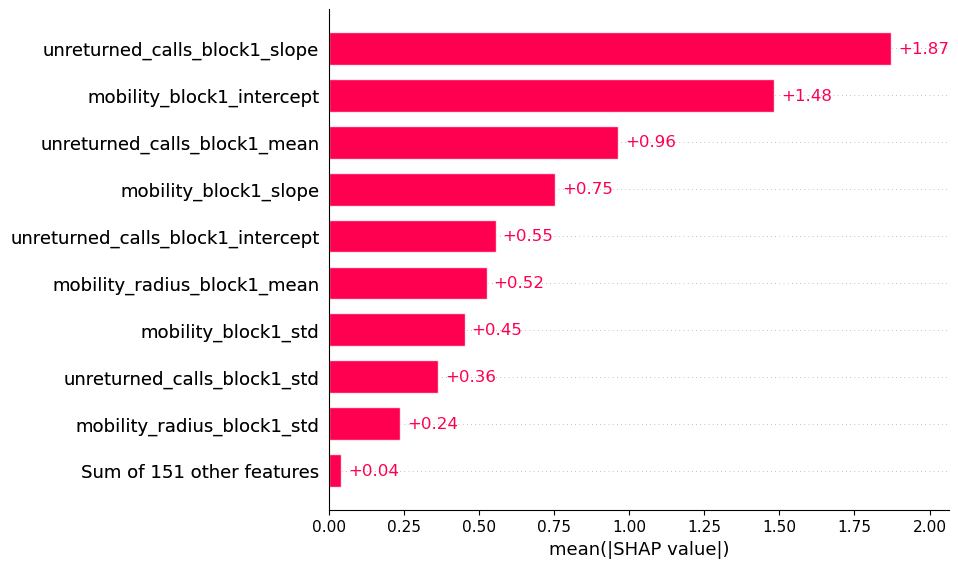

name v1_day y_col phq9_sum_6wks time both model_name HistGradientBoostingRegressor mean r2 0.2405


,columns,shap_values
8,unreturned_calls_block1_slope,1.872804
1,mobility_block1_intercept,1.482703
10,unreturned_calls_block1_mean,0.964157
0,mobility_block1_slope,0.753991
9,unreturned_calls_block1_intercept,0.554922
6,mobility_radius_block1_mean,0.524852
3,mobility_block1_std,0.451539
11,unreturned_calls_block1_std,0.364424
7,mobility_radius_block1_std,0.237517
5,mobility_radius_block1_intercept,0.041578


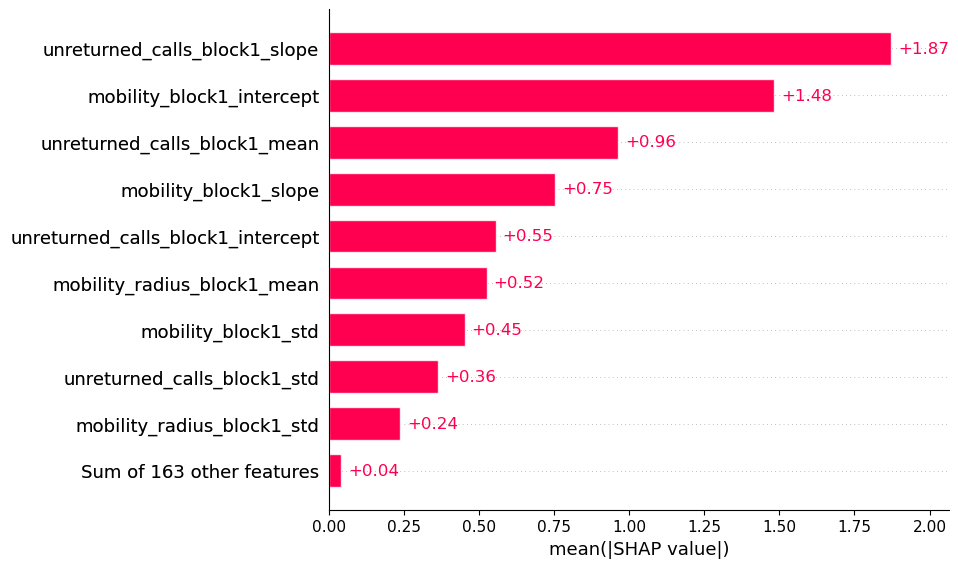

name v1_day y_col phq9_sum_6wks time baseline model_name HistGradientBoostingRegressor mean r2 -0.3487


,columns,shap_values
1,screen_2,1.931467
9,marital_status,0.860355
6,education,0.851304
0,screen_1,0.848174
8,income_satisfaction,0.822053
10,race,0.616430
11,age_category,0.575341
3,screen_4,0.450992
7,working,0.133576
5,gender,0.073922


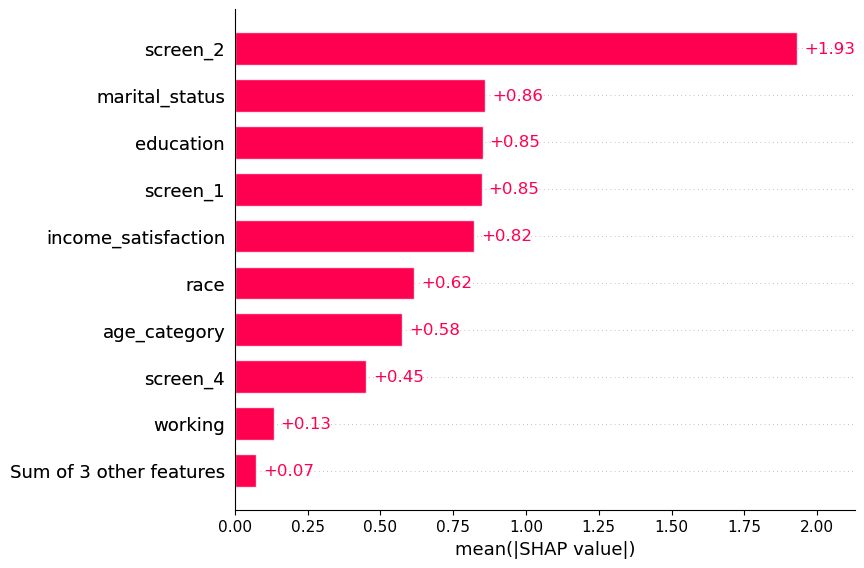

name v1_day y_col 6wks_depressed_binary time 8wks model_name HistGradientBoostingRegressor mean r2 -0.4238
name v1_day y_col 6wks_depressed_binary time both model_name HistGradientBoostingRegressor mean r2 -0.4251
name v1_day y_col 6wks_depressed_binary time baseline model_name HistGradientBoostingRegressor mean r2 -0.7348
name v1_day y_col depression_change_bin time 8wks model_name HistGradientBoostingRegressor mean r2 -0.2412
name v1_day y_col depression_change_bin time both model_name HistGradientBoostingRegressor mean r2 -0.2452
name v1_day y_col depression_change_bin time baseline model_name HistGradientBoostingRegressor mean r2 -0.5929
name v2_day y_col phq9_sum_6wks time 8wks model_name HistGradientBoostingRegressor mean r2 -0.0195


,columns,shap_values
1,distance_high_speed_transportation_hr_block1_i...,2.179622
8,distance_active_hr_block1_slope,1.979741
10,distance_active_hr_block1_mean,0.998923
0,distance_high_speed_transportation_hr_block1_s...,0.809032
3,distance_high_speed_transportation_hr_block1_std,0.580552
11,distance_active_hr_block1_std,0.551900
6,distance_powered_vehicle_hr_block1_mean,0.528503
9,distance_active_hr_block1_intercept,0.494170
7,distance_powered_vehicle_hr_block1_std,0.209391
5,distance_powered_vehicle_hr_block1_intercept,0.036415


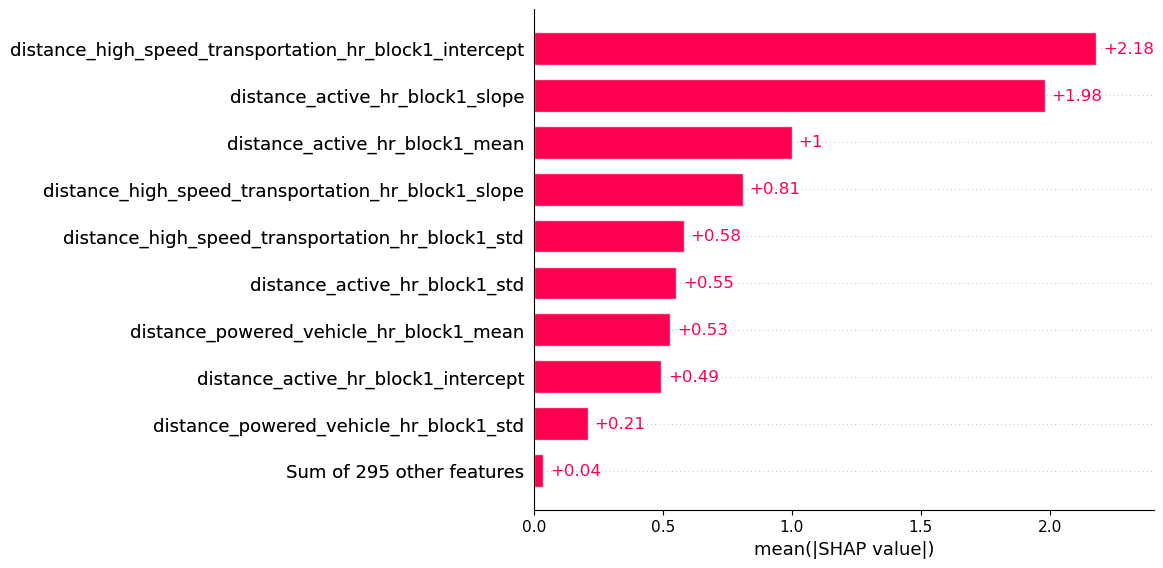

name v2_day y_col phq9_sum_6wks time both model_name HistGradientBoostingRegressor mean r2 -0.0131


,columns,shap_values
1,distance_high_speed_transportation_hr_block1_i...,2.179622
8,distance_active_hr_block1_slope,1.979741
10,distance_active_hr_block1_mean,0.998923
0,distance_high_speed_transportation_hr_block1_s...,0.809032
3,distance_high_speed_transportation_hr_block1_std,0.580552
11,distance_active_hr_block1_std,0.551900
6,distance_powered_vehicle_hr_block1_mean,0.528503
9,distance_active_hr_block1_intercept,0.494170
7,distance_powered_vehicle_hr_block1_std,0.209391
5,distance_powered_vehicle_hr_block1_intercept,0.036415


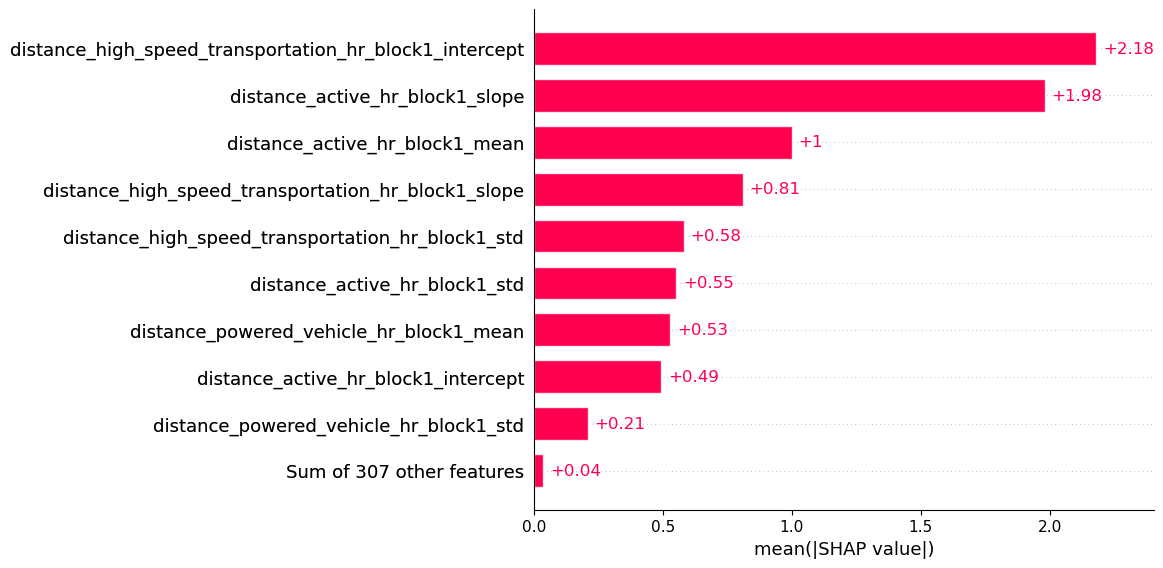

name v2_day y_col phq9_sum_6wks time baseline model_name HistGradientBoostingRegressor mean r2 -0.0719


,columns,shap_values
8,income_satisfaction,1.125366
9,marital_status,0.904603
6,education,0.860350
1,screen_2,0.824231
11,age_category,0.804324
10,race,0.703707
0,screen_1,0.444900
7,working,0.390781
3,screen_4,0.296115
5,gender,0.071423


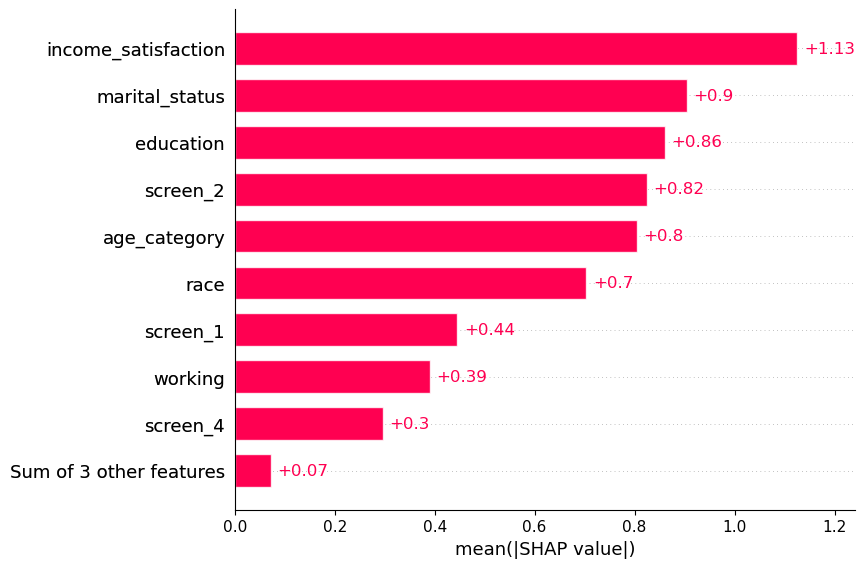

name v2_day y_col 6wks_depressed_binary time 8wks model_name HistGradientBoostingRegressor mean r2 -0.5863
name v2_day y_col 6wks_depressed_binary time both model_name HistGradientBoostingRegressor mean r2 -0.5847
name v2_day y_col 6wks_depressed_binary time baseline model_name HistGradientBoostingRegressor mean r2 -0.9073
name v2_day y_col depression_change_bin time 8wks model_name HistGradientBoostingRegressor mean r2 -0.4585
name v2_day y_col depression_change_bin time both model_name HistGradientBoostingRegressor mean r2 -0.434
name v2_day y_col depression_change_bin time baseline model_name HistGradientBoostingRegressor mean r2 -0.5622


In [60]:
i=0 #change based on which CV you want to see
count=0
top15features = {}
for name, y_dict in model_dict_slopeint.items():
	top15features[name] = {}
	for y_col, type_dict in y_dict.items():
		top15features[name][y_col] = {}
		for time, model_dict in type_dict.items():
			top15features[name][y_col][time]={}
			for model_name, metrics in model_dict.items():
				# mean_r2 = round(np.mean(model_dict_slopeint[name][y_col][time][model_name]['r2_scores']), 3)
				print('name',name, 'y_col',y_col, 'time',time, 'model_name',model_name, 'mean r2', round(np.mean(model_dict_slopeint[name][y_col][time][model_name]['r2_scores']), 4))
		
				model = model_dict_slopeint[name][y_col][time][model_name]['model'][i]
				X_test = model_dict_slopeint[name][y_col][time][model_name]['X_test'][i]
				
				if name == 'v1_day' and y_col == 'start_depressed_binary' and time == '8wks':
					if count<1:
						print(X_test.columns.to_list())
						count=1

				if model is None or X_test is None or len(X_test) == 0:
					continue

				# === Choose the right SHAP explainer dynamically ===
				if y_col in ['start_depressed_binary','6wks_depressed_binary','depression_change_bin']:
					continue
					# fallback to model-agnostic Explainer for Classifier
					explainer = shap.Explainer(model.predict_proba, X_test, feature_names=X_test.columns)
					shap_values = explainer(X_test)

					# SHAP gives one explanation per class → pick positive class (index 1)
					shap_values = shap_values[:, :, 1]
				else:
					# normal tree explainer for Regressor
					explainer = shap.TreeExplainer(model, approximate=True)
					shap_values = explainer(X_test, check_additivity=False)

				# === Plot mean absolute SHAP values per feature ===
				shap_df = pd.DataFrame({
					'columns': X_test.columns,
					'shap_values': np.abs(shap_values.values).mean(axis=0)
				})
				display(shap_df.sort_values('shap_values', ascending=False).head(10))
				top15features[name][y_col][time] = list(shap_df['columns'])[:20]


				shap.plots.bar(shap_values, max_display=10)

				del explainer, shap_values
				gc.collect()

				shap_df = shap_df.sort_values(by='shap_values', ascending=False) #sort from highest to lowest
				

# Using only the top 10 features from feature importance 
### Still slope/int and block1+2 to predict week 6

In [ ]:


model_dict_slopeint_top10 = {}
y_cols =['phq9_sum_6wks', '6wks_depressed_binary', 'depression_change_bin']

models = {
	'HistGradientBoostingRegressor': [HistGradientBoostingRegressor(), HistGradientBoostingClassifier()]
}

for name in ['v1_day','v2_day']: 
	df = pd.read_csv(os.path.join(brighten_dir, f"{name}_wide_slopeintercept_2wk_outcomes.csv"))
	model_dict_slopeint_top10[name] = {}
	

	print(f'####### {name} #######')
	for y_col in y_cols:
		model_dict_slopeint_top10[name][y_col]={}
		df_clean = df.dropna(subset=[y_col])
		model_dict_slopeint_top10[name][y_col] = {}
		for time in ['8wks','both','baseline']:
			model_dict_slopeint_top10[name][y_col][time]={}
			y=df_clean[y_col]
			X=df_clean[top15features[name][y_col][time]]
			non_numeric_cols = X.select_dtypes(include=['object']).columns
			if len(non_numeric_cols) > 0:
				print("Non-numeric columns found:", non_numeric_cols)
				print(X[non_numeric_cols].head())

				
			# Inputs
			groups = df_clean['num_id']
			gkf = GroupKFold(n_splits=5)

			for model_name in models:
				model_dict_slopeint_top10[name][y_col][time][model_name] = {}
				model_dict_slopeint_top10[name][y_col][time][model_name]['model']=[]
				model_dict_slopeint_top10[name][y_col][time][model_name]['X_test']=[]
				model_dict_slopeint_top10[name][y_col][time][model_name]['r2_scores']=[]
				model_dict_slopeint_top10[name][y_col][time][model_name]['mae_scores']=[]
				for train_idx, test_idx in gkf.split(X, y, groups):
					X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
					y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

					if X_train.shape[0]==0 or X_train.shape[1]==0 or len(X_train)==0:
						continue

					model = models[model_name][0]
					if 'bin' in y_col: #binary-- use classifier model instead of regressor model
						model= models[model_name][1]
					model.fit(X_train, y_train)
					model_dict_slopeint_top10[name][y_col][time][model_name]['model'].append(model)

					y_pred = np.round(model.predict(X_test)).astype(int) #ordinal Y
					model_dict_slopeint_top10[name][y_col][time][model_name]['X_test'].append(X_test)

					r2 = r2_score(y_test, y_pred)
					model_dict_slopeint_top10[name][y_col][time][model_name]['r2_scores'].append(r2)

					mae = mean_absolute_error(y_test, y_pred)
					model_dict_slopeint_top10[name][y_col][time][model_name]['mae_scores'].append(mae)
					

				print(f"TIME {time} -- Num features: {len(X_train.columns)}, train: {len(X_train)} obs, test: {len(X_test)} obs || mean R²: {round(np.mean(model_dict_slopeint_top10[name][y_col][time][model_name]['r2_scores']), 4)}, mean MAE: {round(np.mean(model_dict_slopeint_top10[name][y_col][time][model_name]['mae_scores']), 4)} of {round(y.min(), 1)}-{round(y.max(), 1)}\n")



